In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from scipy import stats
from sklearn.cluster import KMeans

In [2]:
# Helper functions
def stoint(col):
    return pd.to_numeric(df_op[col], errors='coerce')

def montoint(col):
    if df_op[col].dtype == object:
        return pd.to_numeric(df_op[col].str.replace(',', '').str.replace('$', '', regex=False), errors='coerce')
    return pd.to_numeric(df_op[col], errors='coerce')

def pertoint(col):
    if df_op[col].dtype == object:
        return pd.to_numeric(df_op[col].str.replace('%', ''), errors='coerce') / 100
    return pd.to_numeric(df_op[col], errors='coerce')

In [3]:
df = pd.read_csv('Medicare_Part_D_Prescribers_by_Provider_2023.csv', low_memory=False)
print(df.shape)


(1380665, 84)


In [4]:
df.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_MI', 'Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_St1',
       'Prscrbr_St2', 'Prscrbr_City', 'Prscrbr_State_Abrvtn',
       'Prscrbr_State_FIPS', 'Prscrbr_zip5', 'Prscrbr_RUCA',
       'Prscrbr_RUCA_Desc', 'Prscrbr_Cntry', 'Prscrbr_Type',
       'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst',
       'Tot_Day_Suply', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms',
       'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply',
       'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'Brnd_Sprsn_Flag',
       'Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Sprsn_Flag',
       'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'Othr_Sprsn_Flag',
       'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'MAPD_Sprsn_Flag',
       'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Sprsn_Flag', 'PDP_Tot_Clms',
       'PDP_Tot_Drug_Cst', 'LIS_Sprsn_Flag', 'LIS_Tot_Clms', 'LIS_Drug_Cst',
       'NonLIS_Sprsn_Flag', 'NonLIS_T

In [5]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

PRSCRBR_NPI                             0
Prscrbr_Last_Org_Name                   0
Prscrbr_First_Name                      2
Prscrbr_MI                         484940
Prscrbr_Crdntls                    134724
Prscrbr_Ent_Cd                          0
Prscrbr_St1                             2
Prscrbr_St2                       1100597
Prscrbr_City                            1
Prscrbr_State_Abrvtn                    0
Prscrbr_State_FIPS                   1534
Prscrbr_zip5                           45
Prscrbr_RUCA                         1534
Prscrbr_RUCA_Desc                    1534
Prscrbr_Cntry                           0
Prscrbr_Type                            3
Prscrbr_Type_src                        0
Tot_Clms                                0
Tot_30day_Fills                         0
Tot_Drug_Cst                            0
Tot_Day_Suply                           0
Tot_Benes                          143405
GE65_Sprsn_Flag                   1052458
GE65_Tot_Clms                     

In [6]:
threshold = 0.5
count = 0
for col in df.columns:
    percnull = df[col].isnull().sum() / len(df)
    if percnull > threshold:
        print(f"{col} Null percentage: {100 * percnull}%")
        count += 1
print(f"\nTotal columns above {100 * threshold}% nan: {count}")

Prscrbr_St2 Null percentage: 79.7149924130763%
GE65_Sprsn_Flag Null percentage: 76.22833924232162%
GE65_Bene_Sprsn_Flag Null percentage: 52.50129466597618%
Brnd_Sprsn_Flag Null percentage: 54.966773257814175%
Gnrc_Sprsn_Flag Null percentage: 97.21829698007845%
Othr_Sprsn_Flag Null percentage: 54.509819543480866%
MAPD_Sprsn_Flag Null percentage: 83.35903350921477%
PDP_Sprsn_Flag Null percentage: 83.35903350921477%
LIS_Sprsn_Flag Null percentage: 79.90113459818275%
NonLIS_Sprsn_Flag Null percentage: 79.90113459818275%
Opioid_LA_Prscrbr_Rate Null percentage: 73.67485957853643%
Antpsyct_GE65_Sprsn_Flag Null percentage: 62.157728341053044%
Antpsyct_GE65_Tot_Benes Null percentage: 64.1141044351816%
Bene_Age_LT_65_Cnt Null percentage: 55.968174756367404%
Bene_Age_65_74_Cnt Null percentage: 50.30677246109665%
Bene_Age_75_84_Cnt Null percentage: 61.400556977978006%
Bene_Age_GT_84_Cnt Null percentage: 68.9262058500795%
Bene_Race_Black_Cnt Null percentage: 57.57609557713131%
Bene_Race_Api_Cnt Nul

In [7]:
df_op = df.copy()

In [8]:
#I kept prescriber city and prescriber type source (ML).

droplist = ['Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_MI', 'Prscrbr_St1', 'Prscrbr_St2',
            'Prscrbr_State_FIPS', 'Prscrbr_RUCA_Desc', 'Othr_Sprsn_Flag',
            'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_Avg_Risk_Scre']
df_op = df_op.drop(columns = droplist)

In [9]:
#note: items() was previously iteritems() in Jacob's data cleaned code.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 134724
Prscrbr_Ent_Cd , 0
Prscrbr_City , 1
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 45
Prscrbr_RUCA , 1534
Prscrbr_Cntry , 0
Prscrbr_Type , 3
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 143405
GE65_Sprsn_Flag , 1052458
GE65_Tot_Clms , 328207
GE65_Tot_30day_Fills , 328207
GE65_Tot_Drug_Cst , 328207
GE65_Tot_Day_Suply , 328207
GE65_Bene_Sprsn_Flag , 724867
GE65_Tot_Benes , 655798
Brnd_Sprsn_Flag , 758907
Brnd_Tot_Clms , 621758
Brnd_Tot_Drug_Cst , 621758
Gnrc_Sprsn_Flag , 1342259
Gnrc_Tot_Clms , 38406
Gnrc_Tot_Drug_Cst , 38406
MAPD_Sprsn_Flag , 1150909
MAPD_Tot_Clms , 229756
MAPD_Tot_Drug_Cst , 229756
PDP_Sprsn_Flag , 1150909
PDP_Tot_Clms , 229756
PDP_Tot_Drug_Cst , 229756
LIS_Sprsn_Flag , 1103167
LIS_Tot_Clms , 277498
LIS_Drug_Cst , 277498
NonLIS_Sprsn_Flag , 1103167
NonLIS_Tot_Clms , 277498
NonLIS_Drug_Cst , 277498
Opioid_Tot_Clms , 347477
Opioid_Tot_Drug_Cst , 347477
Opioid_Tot_Suply , 347477
Opio

In [10]:
#Prscbr
#changed df_op['Prscrbr_Crdntls'].fillna('Organization') to df_op['Prscrbr_Crdntls'].fillna('Unknown').

df_op['Prscrbr_Crdntls'] = df_op['Prscrbr_Crdntls'].fillna('Unknown')

df_op['Prscrbr_City'] = df_op['Prscrbr_City'].fillna('Unknown')

df_op['Prscrbr_zip5'] = df_op['Prscrbr_zip5'].fillna('Unknown')

df_op['Prscrbr_RUCA'] = df_op['Prscrbr_RUCA'].fillna('Unknown')

df_op['Prscrbr_Type'] = df_op['Prscrbr_Type'].fillna('Unknown')

In [11]:
print(df['Tot_Clms'].dtype)
print(df['Tot_Clms'].head())

int64
0     222
1    1865
2     118
3     162
4      41
Name: Tot_Clms, dtype: int64


In [12]:
#Totals

df_op['Tot_Clms'] = stoint('Tot_Clms')

df_op['Tot_30day_Fills'] = stoint('Tot_30day_Fills')

df_op['Tot_Drug_Cst'] = montoint('Tot_Drug_Cst')

df_op['Tot_Day_Suply'] = stoint('Tot_Day_Suply')

df_op['Tot_Benes'] = stoint('Tot_Benes').fillna(10)

In [13]:
#GE65
df_op['GE65_Sprsn_Flag'] = df_op['GE65_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Clms'] = stoint('GE65_Tot_Clms').fillna(10)

df_op['GE65_Tot_30day_Fills'] = stoint('GE65_Tot_30day_Fills')
df_op['GE65_Tot_30day_Fills'] = df_op['GE65_Tot_30day_Fills'].fillna(df_op['GE65_Tot_30day_Fills'].min())

df_op['GE65_Tot_Drug_Cst'] = montoint('GE65_Tot_Drug_Cst')
df_op['GE65_Tot_Drug_Cst'] = df_op['GE65_Tot_Drug_Cst'].fillna(df_op['GE65_Tot_Drug_Cst'].min())

df_op['GE65_Tot_Day_Suply'] = stoint('GE65_Tot_Day_Suply')
df_op['GE65_Tot_Day_Suply'] = df_op['GE65_Tot_Day_Suply'].fillna(df_op['GE65_Tot_Day_Suply'].min())

df_op['GE65_Bene_Sprsn_Flag'] = df_op['GE65_Bene_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Benes'] = stoint('GE65_Tot_Benes')
df_op['GE65_Tot_Benes'] = df_op['GE65_Tot_Benes'].fillna(10)


In [14]:
#BRND

df_op['Brnd_Sprsn_Flag'] = df_op['Brnd_Sprsn_Flag'].notna().astype(int)

df_op['Brnd_Tot_Clms'] = stoint('Brnd_Tot_Clms')
df_op['Brnd_Tot_Clms'] = df_op['Brnd_Tot_Clms'].fillna(10)

df_op['Brnd_Tot_Drug_Cst'] = montoint('Brnd_Tot_Drug_Cst')
df_op['Brnd_Tot_Drug_Cst'] = df_op['Brnd_Tot_Drug_Cst'].fillna(df_op['Brnd_Tot_Drug_Cst'].min())

In [15]:
#GNRC

df_op['Gnrc_Sprsn_Flag'] = df_op['Gnrc_Sprsn_Flag'].notna().astype(int)

df_op['Gnrc_Tot_Clms'] = stoint('Gnrc_Tot_Clms')
df_op['Gnrc_Tot_Clms'] = df_op['Gnrc_Tot_Clms'].fillna(10)

df_op['Gnrc_Tot_Drug_Cst'] = montoint('Gnrc_Tot_Drug_Cst')
df_op['Gnrc_Tot_Drug_Cst'] = df_op['Gnrc_Tot_Drug_Cst'].fillna(df_op['Gnrc_Tot_Drug_Cst'].min())

In [16]:
#MAPD

df_op['MAPD_Sprsn_Flag'] = df_op['MAPD_Sprsn_Flag'].notna().astype(int)

df_op['MAPD_Tot_Clms'] = stoint('MAPD_Tot_Clms')
df_op['MAPD_Tot_Clms'] = df_op['MAPD_Tot_Clms'].fillna(10)

df_op['MAPD_Tot_Drug_Cst'] = montoint('MAPD_Tot_Drug_Cst')
df_op['MAPD_Tot_Drug_Cst'] = df_op['MAPD_Tot_Drug_Cst'].fillna(df_op['MAPD_Tot_Drug_Cst'].min())

In [17]:
#PDP

df_op['PDP_Sprsn_Flag'] = df_op['PDP_Sprsn_Flag'].notna().astype(int)

df_op['PDP_Tot_Clms'] = stoint('PDP_Tot_Clms')
df_op['PDP_Tot_Clms'] = df_op['PDP_Tot_Clms'].fillna(10)

df_op['PDP_Tot_Drug_Cst'] = montoint('PDP_Tot_Drug_Cst')
df_op['PDP_Tot_Drug_Cst'] = df_op['PDP_Tot_Drug_Cst'].fillna(df_op['PDP_Tot_Drug_Cst'].min())

In [18]:
#LIS

df_op['LIS_Sprsn_Flag'] = df_op['LIS_Sprsn_Flag'].notna().astype(int)

df_op['LIS_Tot_Clms'] = stoint('LIS_Tot_Clms')
df_op['LIS_Tot_Clms'] = df_op['LIS_Tot_Clms'].fillna(10)

df_op['LIS_Drug_Cst'] = montoint('LIS_Drug_Cst')
df_op['LIS_Drug_Cst'] = df_op['LIS_Drug_Cst'].fillna(df_op['LIS_Drug_Cst'].min())

In [19]:
#NonLIS

df_op['NonLIS_Sprsn_Flag'] = df_op['NonLIS_Sprsn_Flag'].notna().astype(int)

df_op['NonLIS_Tot_Clms'] = stoint('NonLIS_Tot_Clms')
df_op['NonLIS_Tot_Clms'] = df_op['NonLIS_Tot_Clms'].fillna(10)

df_op['NonLIS_Drug_Cst'] = montoint('NonLIS_Drug_Cst')
df_op['NonLIS_Drug_Cst'] = df_op['NonLIS_Drug_Cst'].fillna(df_op['NonLIS_Drug_Cst'].min())

In [20]:
#Opioid

df_op['Opioid_Tot_Clms'] = stoint('Opioid_Tot_Clms')
df_op['Opioid_Tot_Clms'] = df_op['Opioid_Tot_Clms'].fillna(10)

df_op['Opioid_Tot_Drug_Cst'] = montoint('Opioid_Tot_Drug_Cst')
df_op['Opioid_Tot_Drug_Cst'] = df_op['Opioid_Tot_Drug_Cst'].fillna(df_op['Opioid_Tot_Drug_Cst'].min())

df_op['Opioid_Tot_Suply'] = stoint('Opioid_Tot_Suply')
df_op['Opioid_Tot_Suply'] = df_op['Opioid_Tot_Suply'].fillna(df_op['Opioid_Tot_Suply'].min())

df_op['Opioid_Tot_Benes'] = stoint('Opioid_Tot_Benes')
df_op['Opioid_Tot_Benes'] = df_op['Opioid_Tot_Benes'].fillna(10)

df_op['Opioid_Prscrbr_Rate'] = pertoint('Opioid_Prscrbr_Rate')
df_op['Opioid_Prscrbr_Rate'] = df_op['Opioid_Prscrbr_Rate'].fillna(df_op['Opioid_Prscrbr_Rate'].min())

df_op['Opioid_LA_Tot_Clms'] = stoint('Opioid_LA_Tot_Clms')
df_op['Opioid_LA_Tot_Clms'] = df_op['Opioid_LA_Tot_Clms'].fillna(10)

df_op['Opioid_LA_Tot_Drug_Cst'] = montoint('Opioid_LA_Tot_Drug_Cst')
df_op['Opioid_LA_Tot_Drug_Cst'] = df_op['Opioid_LA_Tot_Drug_Cst'].fillna(df_op['Opioid_LA_Tot_Drug_Cst'].min())

df_op['Opioid_LA_Tot_Suply'] = stoint('Opioid_LA_Tot_Suply')
df_op['Opioid_LA_Tot_Suply'] = df_op['Opioid_LA_Tot_Suply'].fillna(df_op['Opioid_LA_Tot_Suply'].min())

df_op['Opioid_LA_Tot_Benes'] = stoint('Opioid_LA_Tot_Benes')
df_op['Opioid_LA_Tot_Benes'] = df_op['Opioid_LA_Tot_Benes'].fillna(10)

df_op['Opioid_LA_Prscrbr_Rate'] = pertoint('Opioid_LA_Prscrbr_Rate')
df_op['Opioid_LA_Prscrbr_Rate'] = df_op['Opioid_LA_Prscrbr_Rate'].fillna(df_op['Opioid_LA_Prscrbr_Rate'].min())


In [21]:
#Antibiotic

df_op['Antbtc_Tot_Clms'] = stoint('Antbtc_Tot_Clms')
df_op['Antbtc_Tot_Clms'] = df_op['Antbtc_Tot_Clms'].fillna(10)

df_op['Antbtc_Tot_Drug_Cst'] = montoint('Antbtc_Tot_Drug_Cst')
df_op['Antbtc_Tot_Drug_Cst'] = df_op['Antbtc_Tot_Drug_Cst'].fillna(df_op['Antbtc_Tot_Drug_Cst'].min())

df_op['Antbtc_Tot_Benes'] = stoint('Antbtc_Tot_Benes')
df_op['Antbtc_Tot_Benes'] = df_op['Antbtc_Tot_Benes'].fillna(10)

In [22]:
#Antipsychotic

df_op['Antpsyct_GE65_Sprsn_Flag'] = df_op['Antpsyct_GE65_Sprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Clms'] = stoint('Antpsyct_GE65_Tot_Clms')
df_op['Antpsyct_GE65_Tot_Clms'] = df_op['Antpsyct_GE65_Tot_Clms'].fillna(10)

df_op['Antpsyct_GE65_Tot_Drug_Cst'] = montoint('Antpsyct_GE65_Tot_Drug_Cst')
df_op['Antpsyct_GE65_Tot_Drug_Cst'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'].fillna(df_op['Antpsyct_GE65_Tot_Drug_Cst'].min())

df_op['Antpsyct_GE65_Bene_Suprsn_Flag'] = df_op['Antpsyct_GE65_Bene_Suprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Benes'] = stoint('Antpsyct_GE65_Tot_Benes')
df_op['Antpsyct_GE65_Tot_Benes'] = df_op['Antpsyct_GE65_Tot_Benes'].fillna(10)


In [23]:
#Bene Age

df_op['Bene_Avg_Age'] = df_op['Bene_Avg_Age'].fillna(df_op['Bene_Avg_Age'].mode()[0])

df_op['Bene_Age_LT_65_Cnt'] = stoint('Bene_Age_LT_65_Cnt').fillna(10)

df_op['Bene_Age_GT_84_Cnt'] = stoint('Bene_Age_GT_84_Cnt').fillna(10)

df_op['Bene_Age_65_74_Cnt'] = stoint('Bene_Age_65_74_Cnt')
df_op['Bene_Age_75_84_Cnt'] = stoint('Bene_Age_75_84_Cnt')
df_op['Bene_Age_65_74_Cnt'] = df_op['Bene_Age_65_74_Cnt'].fillna(0)
df_op['Bene_Age_75_84_Cnt'] = df_op['Bene_Age_75_84_Cnt'].fillna(0)
df_op['Bene_Age_65_84_Cnt'] = df_op['Bene_Age_65_74_Cnt'] + df_op['Bene_Age_75_84_Cnt']
df_op = df_op.drop(columns = ['Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt'])

In [24]:
#Bene Sex

df_op['Bene_Feml_Cnt'] = stoint('Bene_Feml_Cnt')
df_op['Bene_Feml_Cnt'] = df_op['Bene_Feml_Cnt'].fillna(10)

df_op['Bene_Male_Cnt'] = stoint('Bene_Male_Cnt')
df_op['Bene_Male_Cnt'] = df_op['Bene_Male_Cnt'].fillna(10)

In [25]:
#Bene Race

df_op['Bene_Race_Wht_Cnt'] = stoint('Bene_Race_Wht_Cnt')
df_op['Bene_Race_Wht_Cnt'] = df_op['Bene_Race_Wht_Cnt'].fillna(10)

df_op['Bene_Race_Black_Cnt'] = stoint('Bene_Race_Black_Cnt')
df_op['Bene_Race_Black_Cnt'] = df_op['Bene_Race_Black_Cnt'].fillna(10)

df_op['Bene_Race_Api_Cnt'] = stoint('Bene_Race_Api_Cnt')
df_op['Bene_Race_Api_Cnt'] = df_op['Bene_Race_Api_Cnt'].fillna(10)

df_op['Bene_Race_Hspnc_Cnt'] = stoint('Bene_Race_Hspnc_Cnt')
df_op['Bene_Race_Hspnc_Cnt'] = df_op['Bene_Race_Hspnc_Cnt'].fillna(10)

#df_op['Bene_Race_Natind_Cnt'] = stoint('Bene_Race_Natind_Cnt') Already float
df_op['Bene_Race_Natind_Cnt'] = df_op['Bene_Race_Natind_Cnt'].fillna(10)

df_op['Bene_Race_Othr_Cnt'] = stoint('Bene_Race_Othr_Cnt')
df_op['Bene_Race_Othr_Cnt'] = df_op['Bene_Race_Othr_Cnt'].fillna(10)

In [26]:
#note: items() was previously iteritems() in Jacob's cleaned data.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 0
Prscrbr_Ent_Cd , 0
Prscrbr_City , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 0
Prscrbr_RUCA , 0
Prscrbr_Cntry , 0
Prscrbr_Type , 0
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 0
GE65_Sprsn_Flag , 0
GE65_Tot_Clms , 0
GE65_Tot_30day_Fills , 0
GE65_Tot_Drug_Cst , 0
GE65_Tot_Day_Suply , 0
GE65_Bene_Sprsn_Flag , 0
GE65_Tot_Benes , 0
Brnd_Sprsn_Flag , 0
Brnd_Tot_Clms , 0
Brnd_Tot_Drug_Cst , 0
Gnrc_Sprsn_Flag , 0
Gnrc_Tot_Clms , 0
Gnrc_Tot_Drug_Cst , 0
MAPD_Sprsn_Flag , 0
MAPD_Tot_Clms , 0
MAPD_Tot_Drug_Cst , 0
PDP_Sprsn_Flag , 0
PDP_Tot_Clms , 0
PDP_Tot_Drug_Cst , 0
LIS_Sprsn_Flag , 0
LIS_Tot_Clms , 0
LIS_Drug_Cst , 0
NonLIS_Sprsn_Flag , 0
NonLIS_Tot_Clms , 0
NonLIS_Drug_Cst , 0
Opioid_Tot_Clms , 0
Opioid_Tot_Drug_Cst , 0
Opioid_Tot_Suply , 0
Opioid_Tot_Benes , 0
Opioid_Prscrbr_Rate , 0
Opioid_LA_Tot_Clms , 0
Opioid_LA_Tot_Drug_Cst , 0
Opioid_LA_Tot_Suply , 0
Opioid_LA_Tot_Benes , 0
Opioid_LA_Prscrbr_R

In [27]:
df_op.isnull().sum().sum()

np.int64(0)

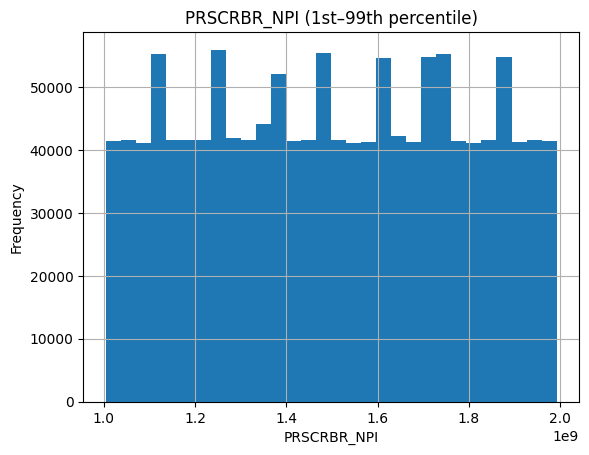

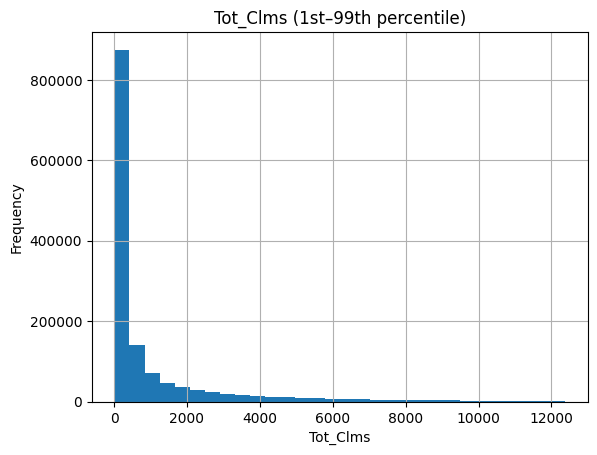

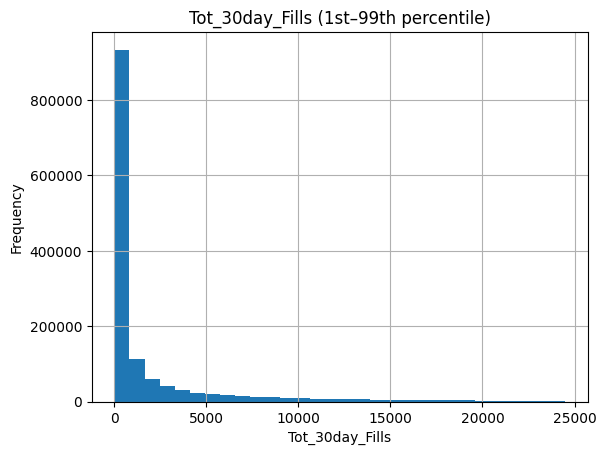

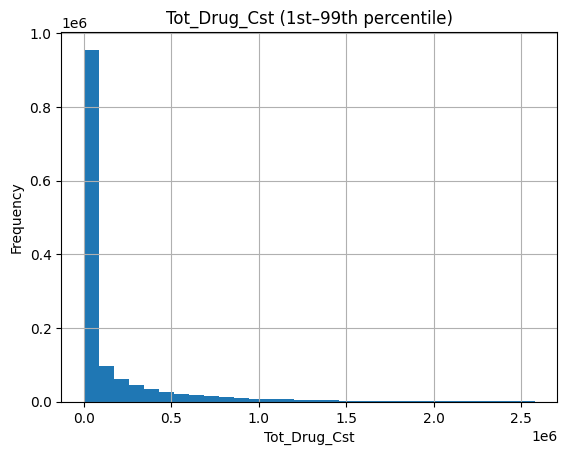

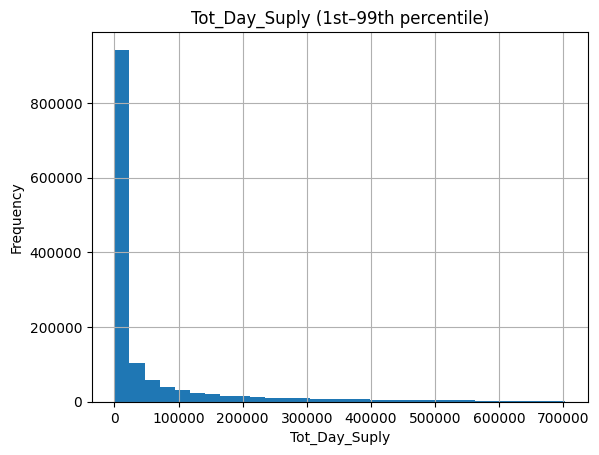

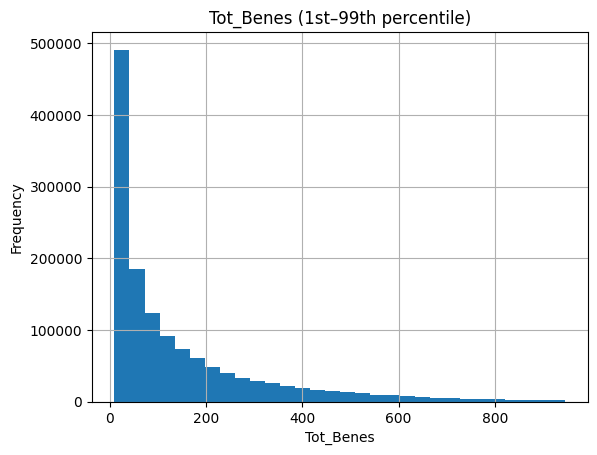

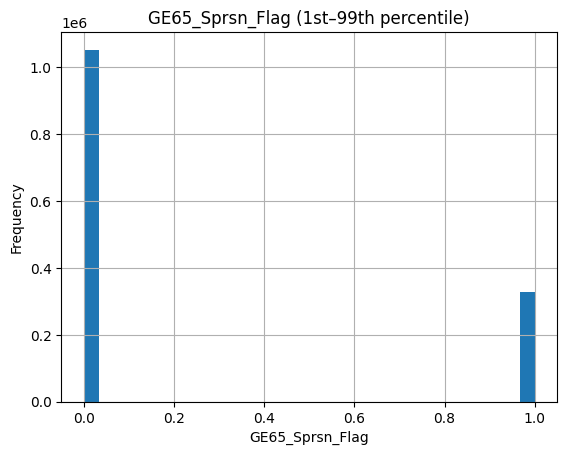

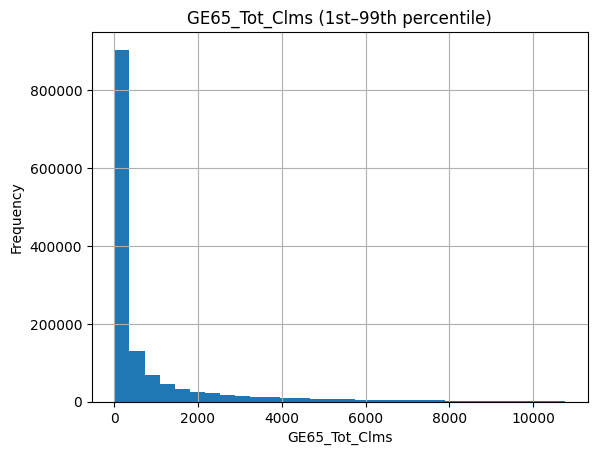

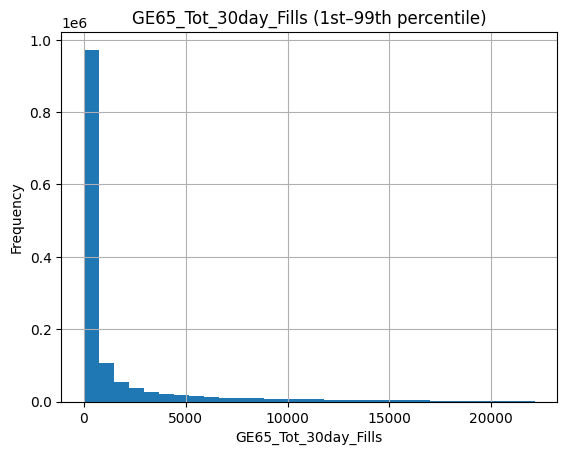

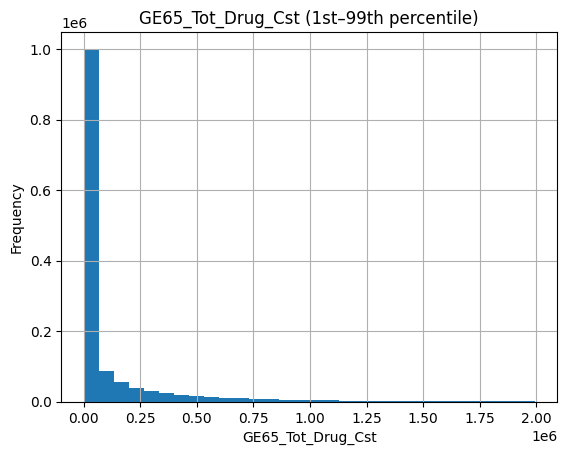

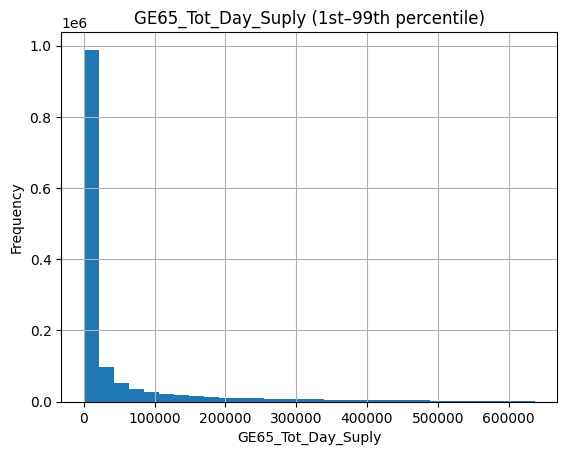

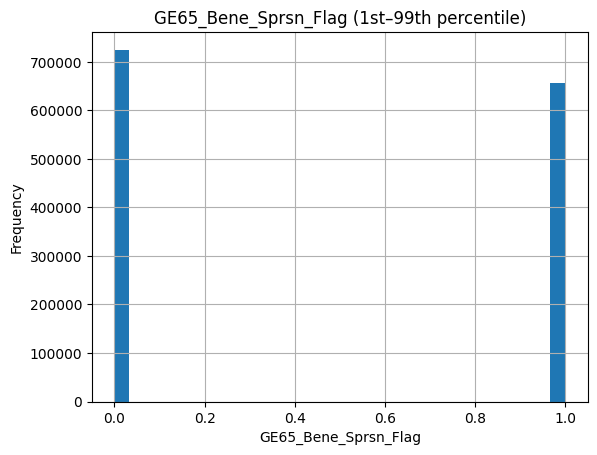

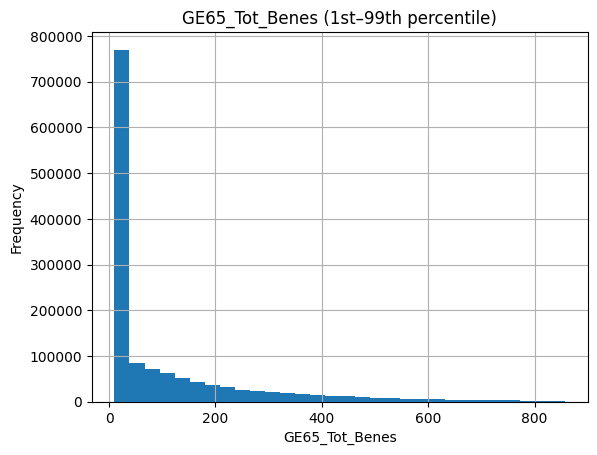

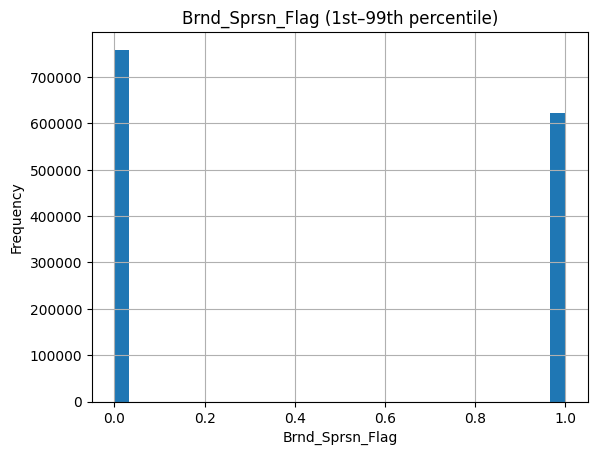

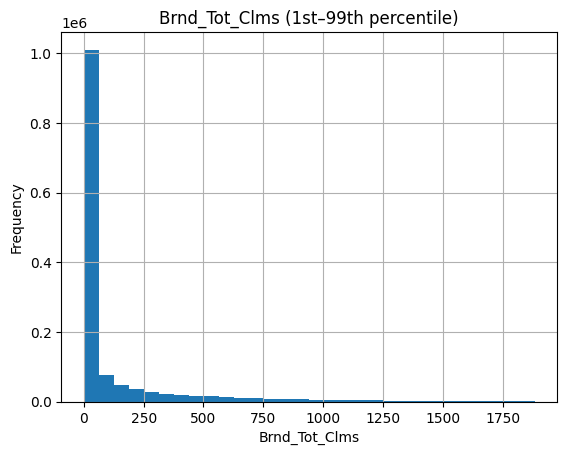

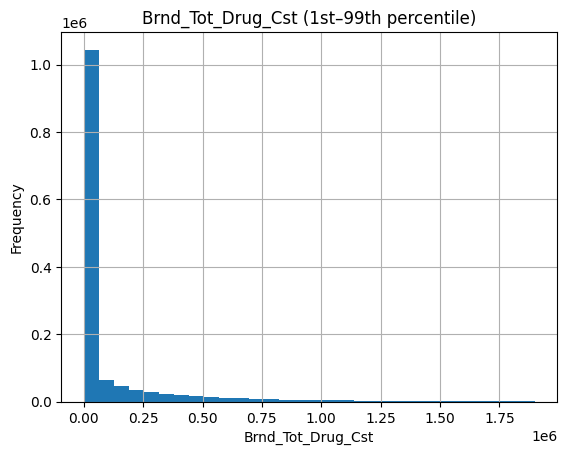

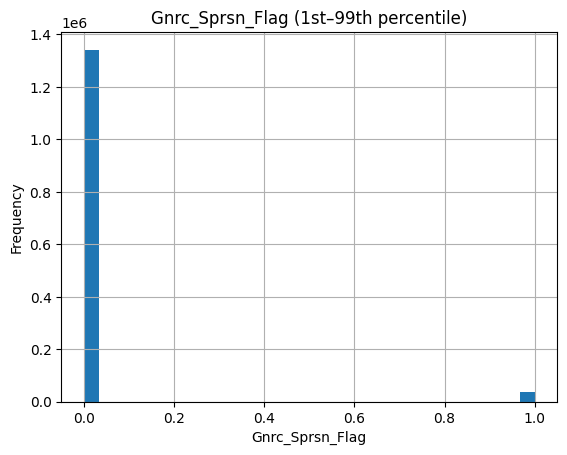

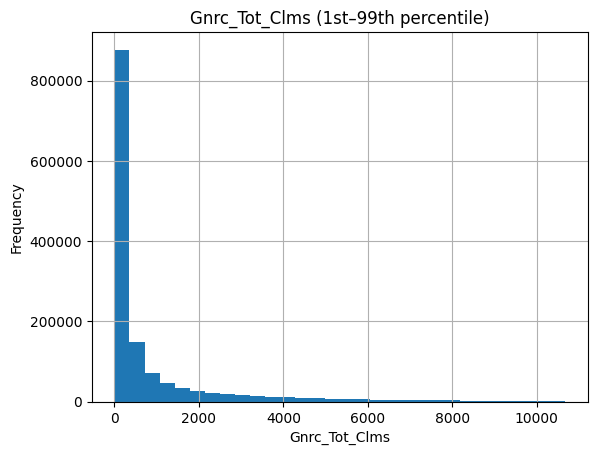

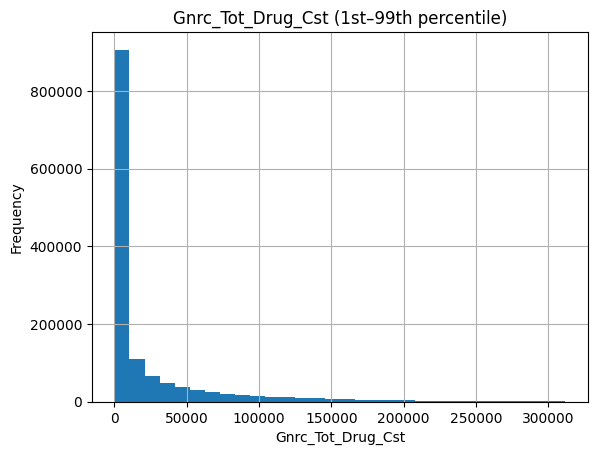

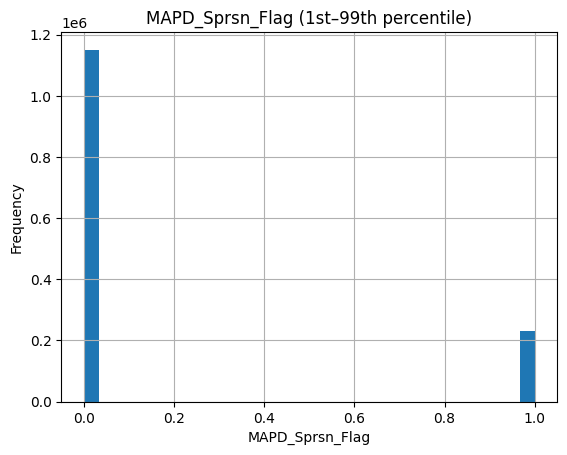

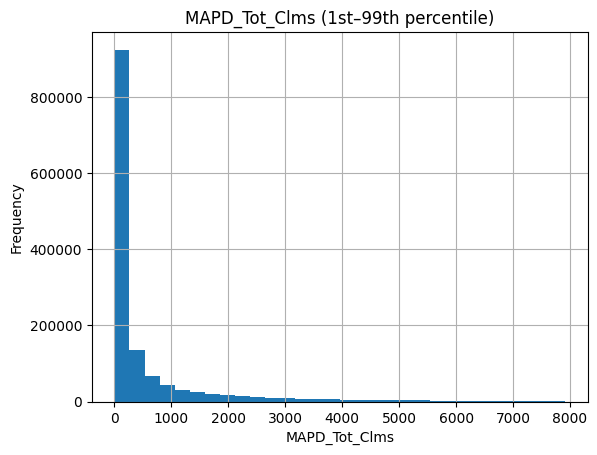

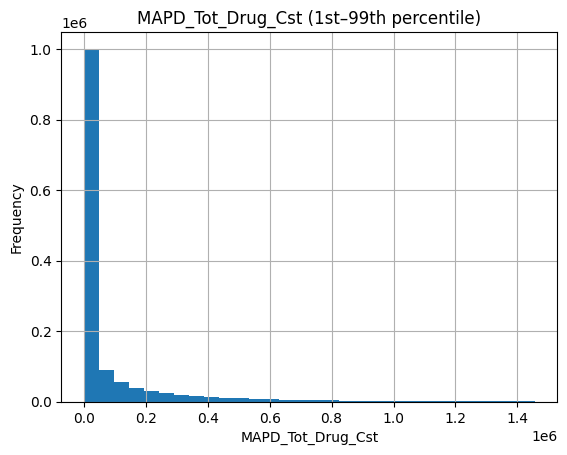

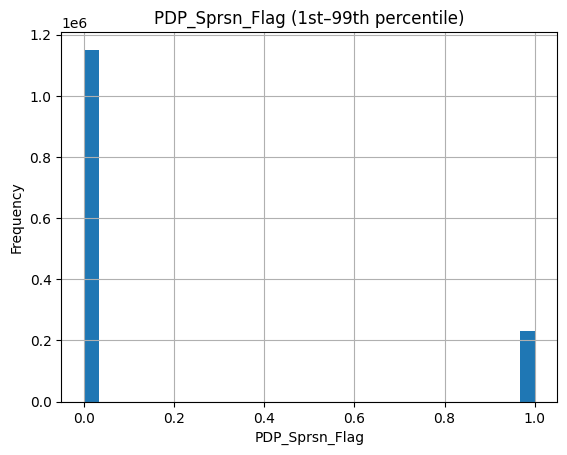

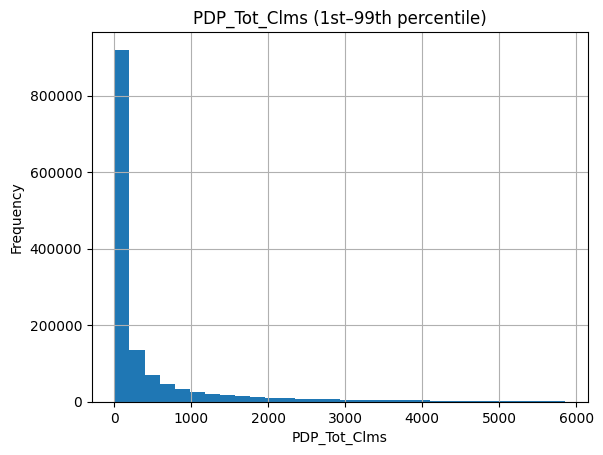

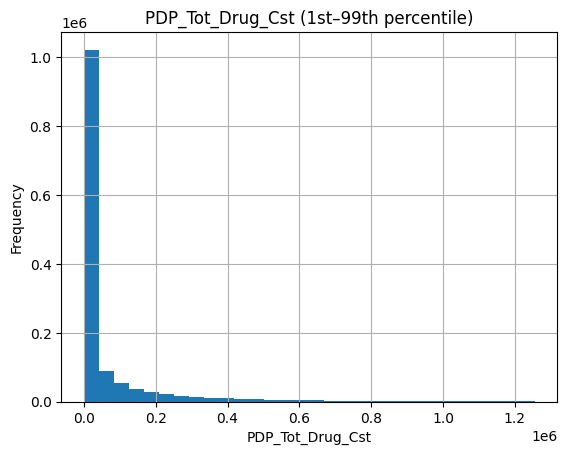

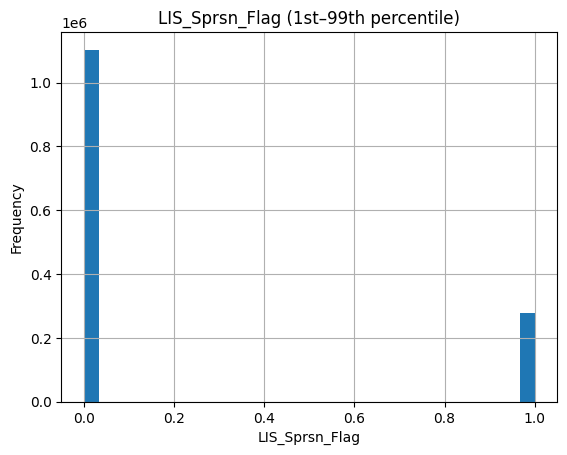

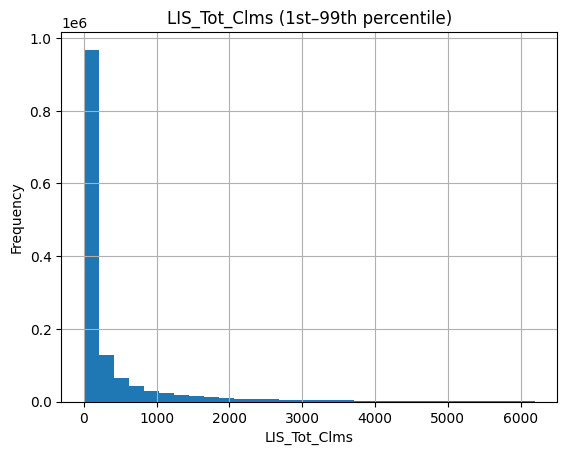

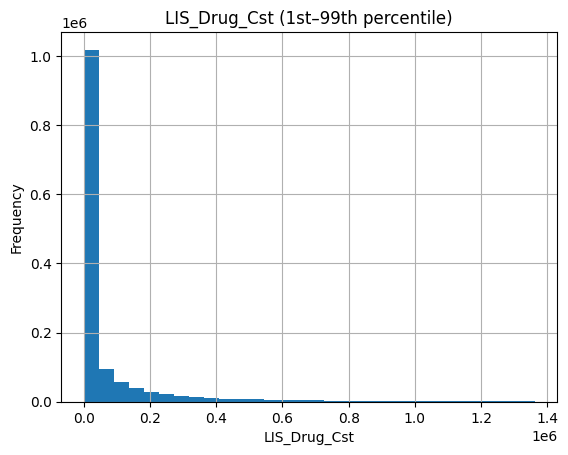

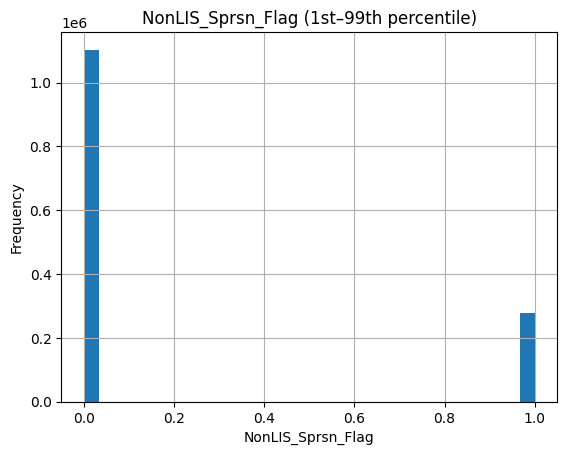

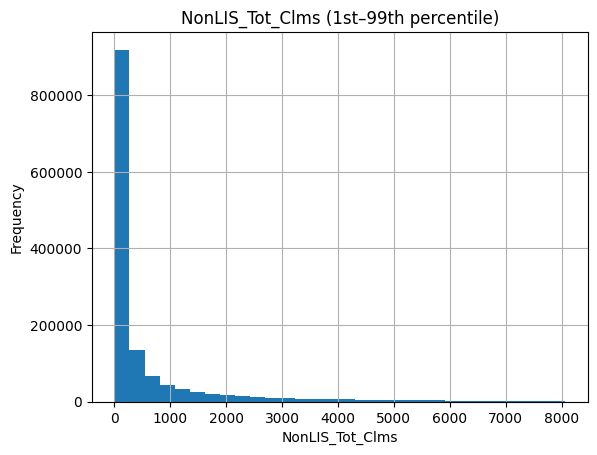

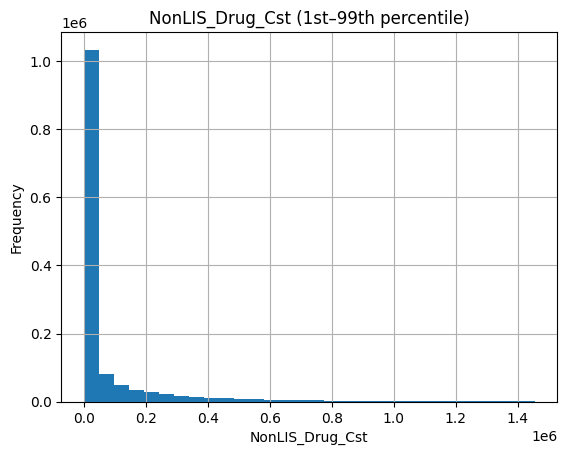

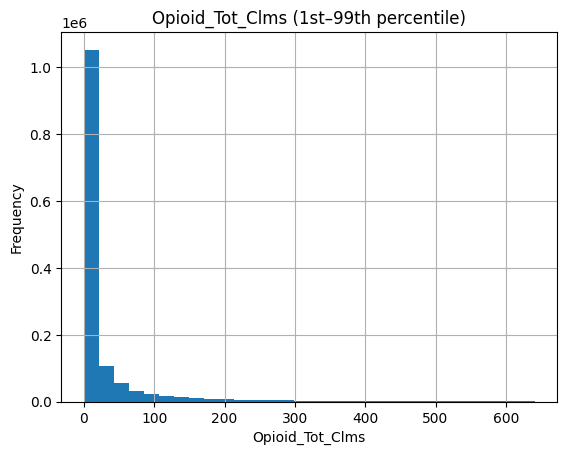

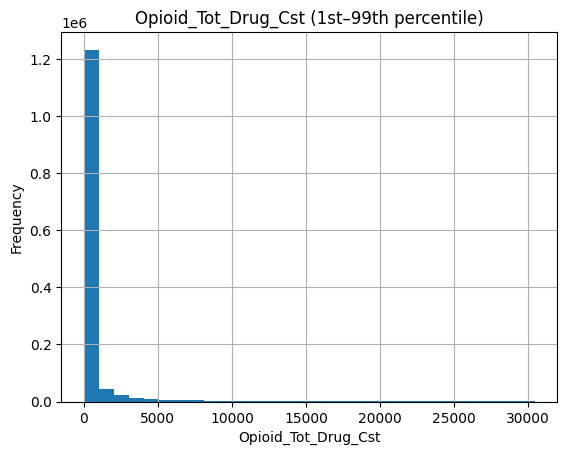

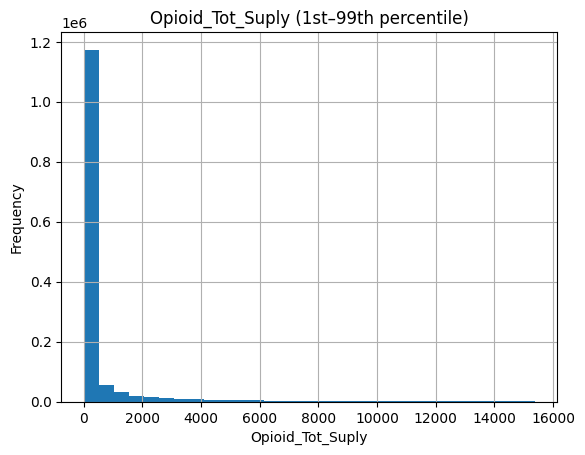

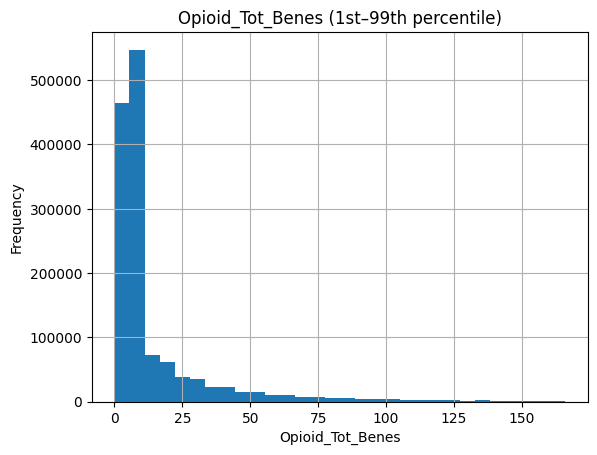

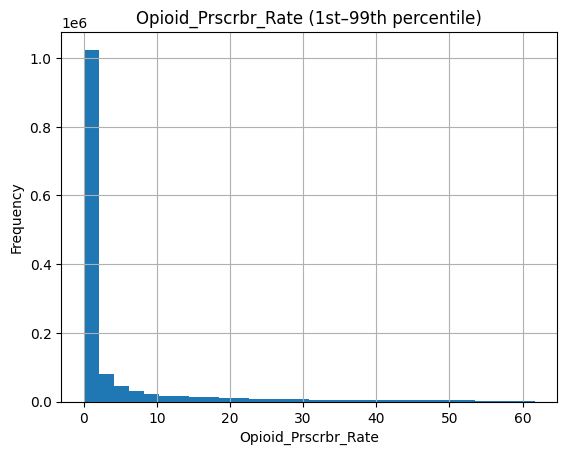

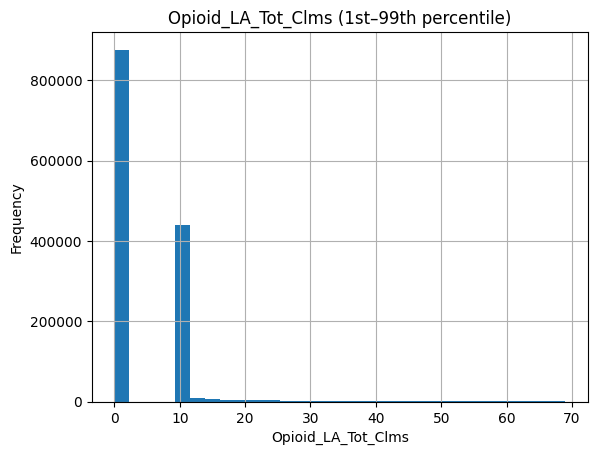

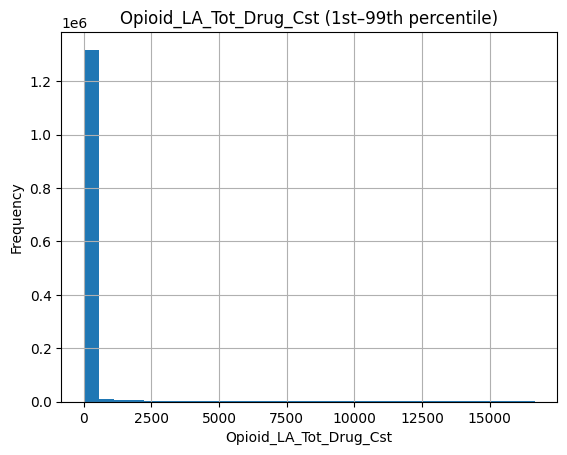

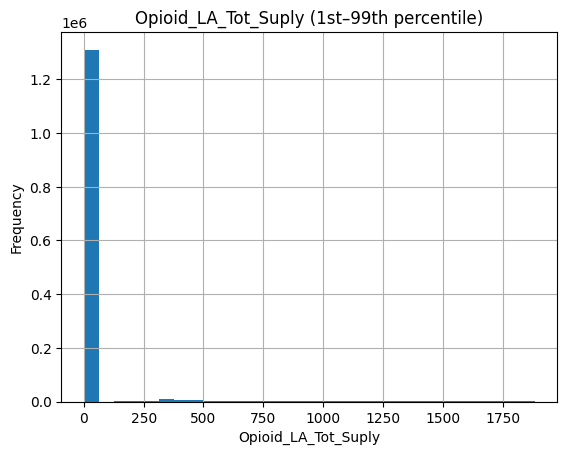

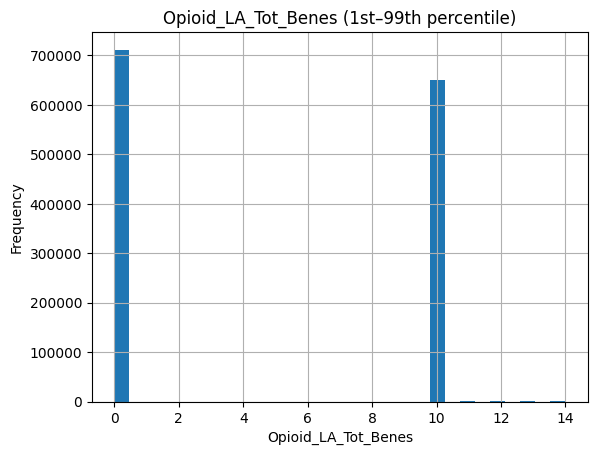

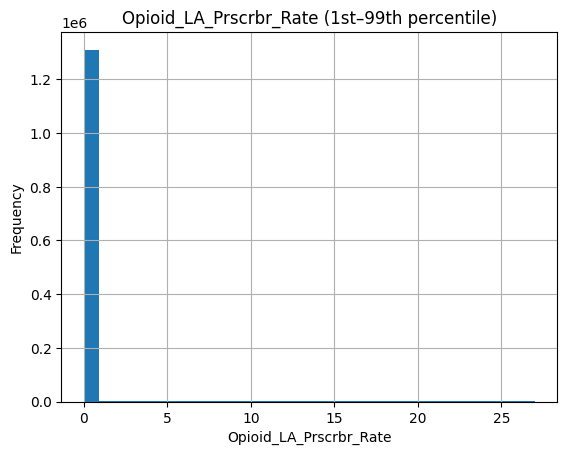

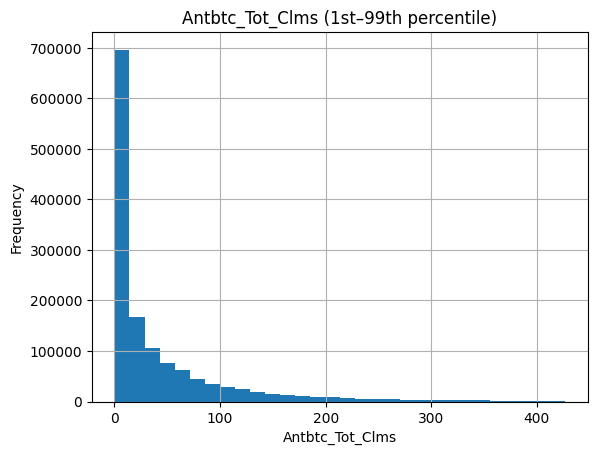

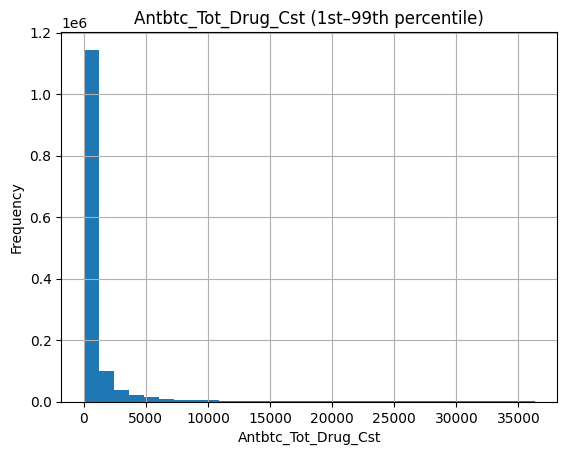

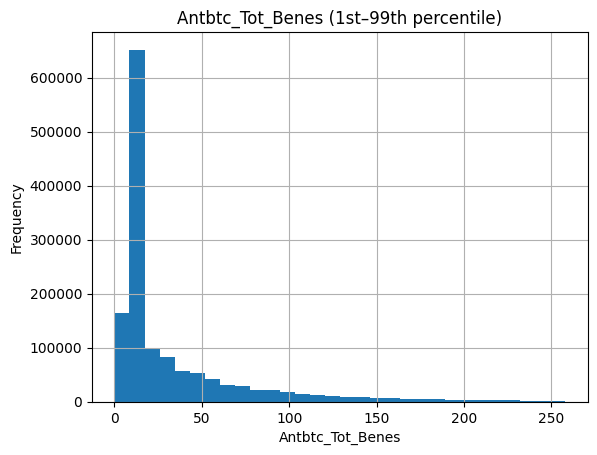

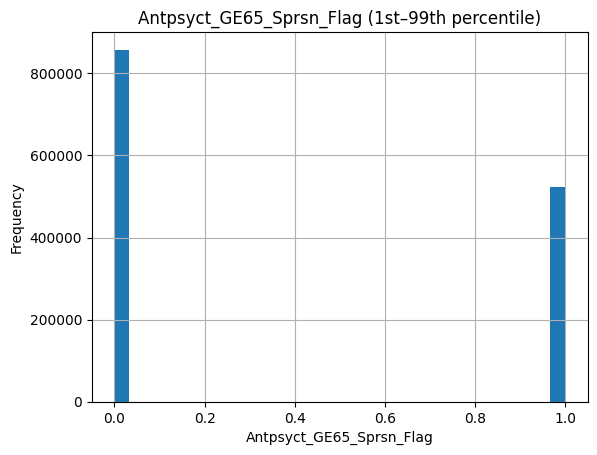

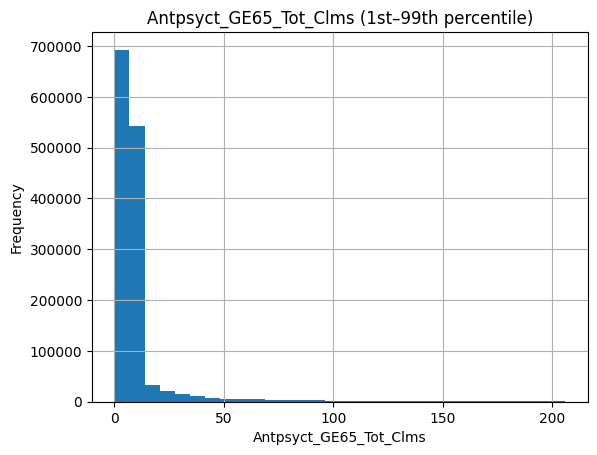

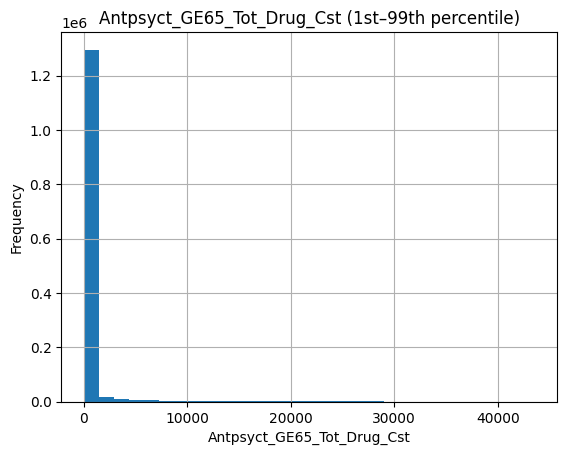

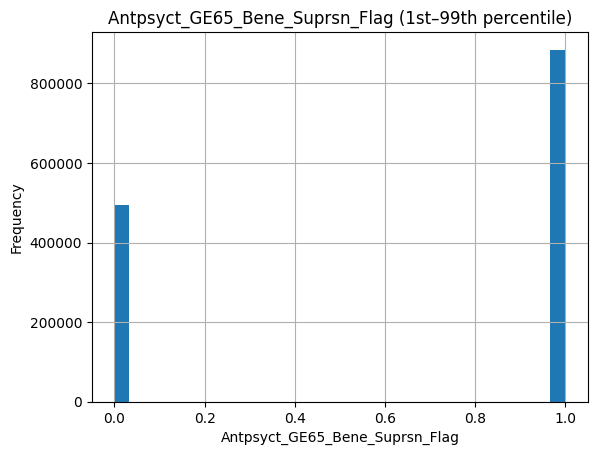

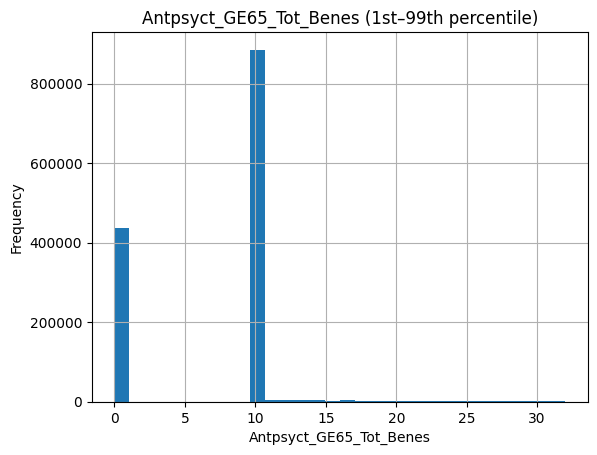

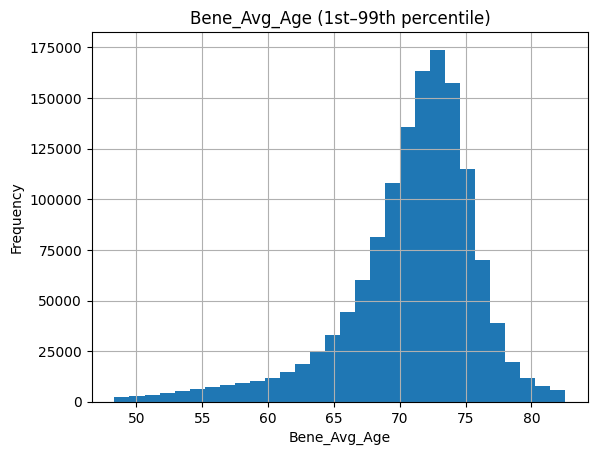

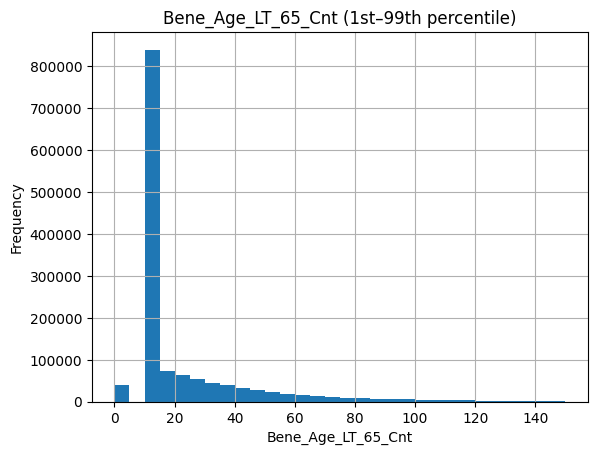

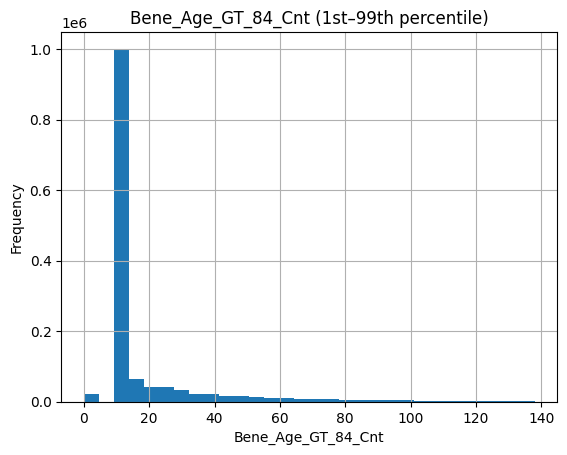

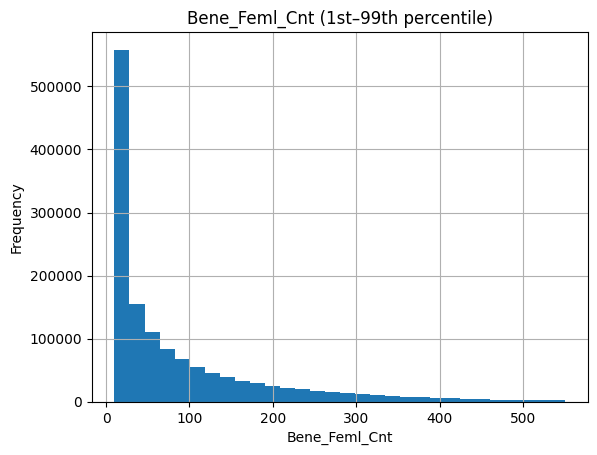

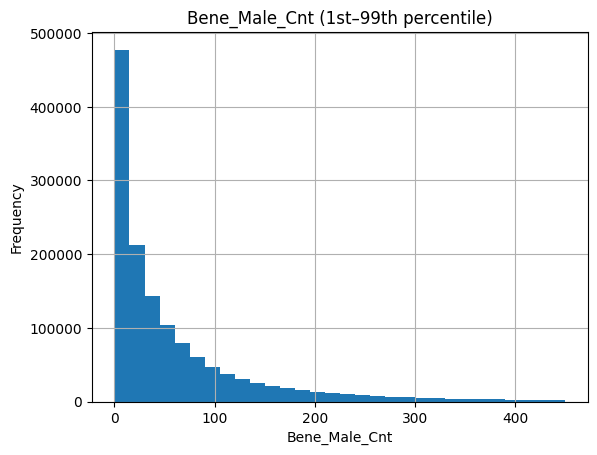

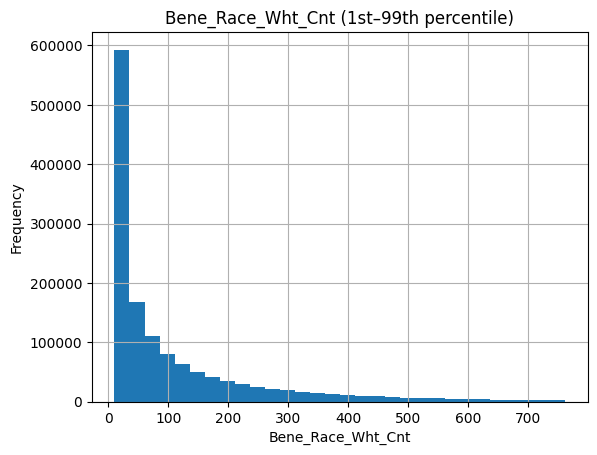

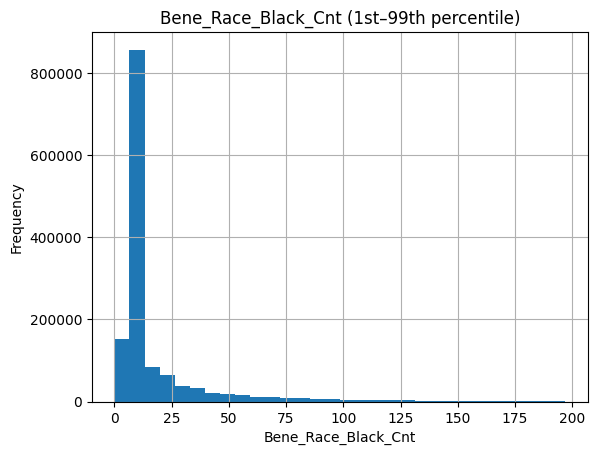

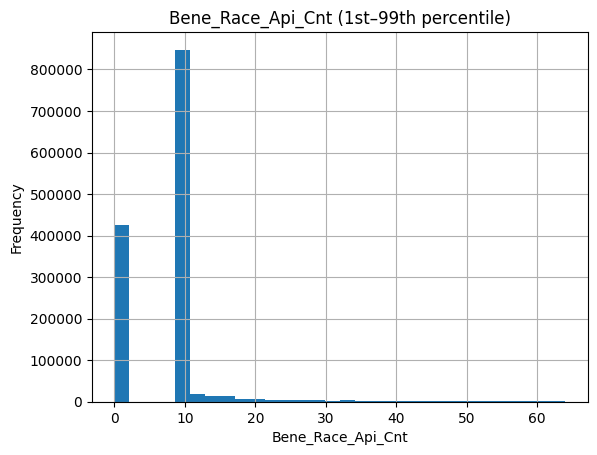

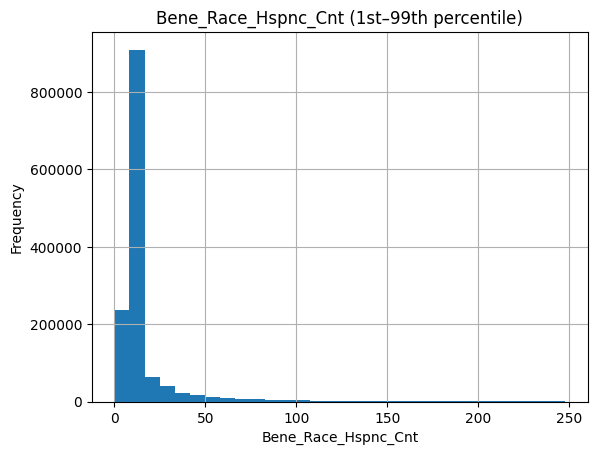

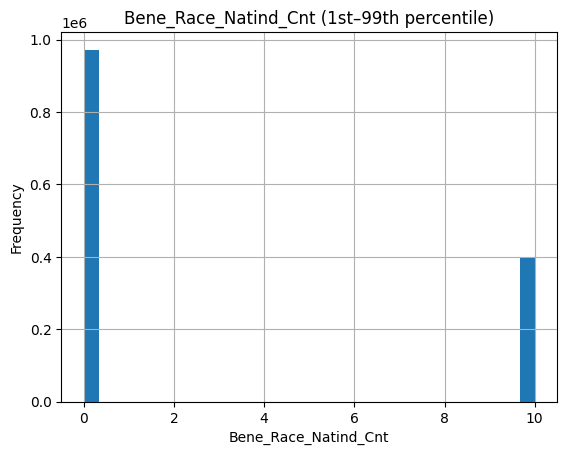

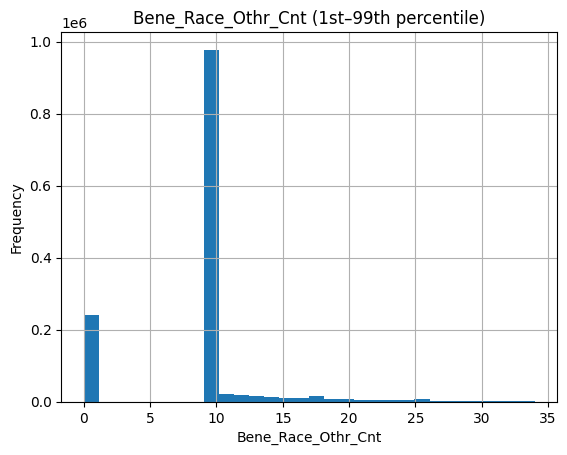

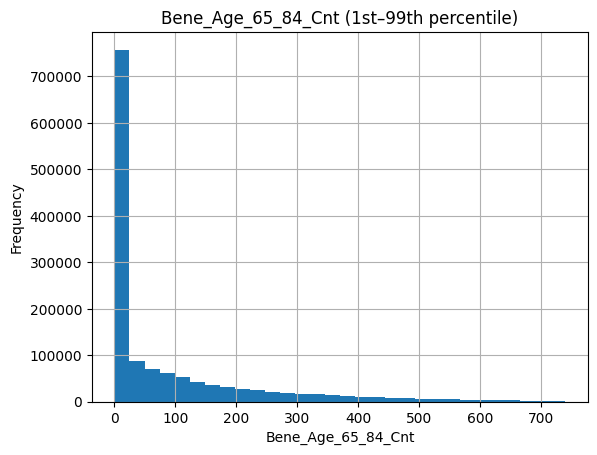

In [28]:
num_cols = df_op.select_dtypes(include='number').columns

for col in num_cols:
    lower = df_op[col].quantile(0.01)
    upper = df_op[col].quantile(0.99)
    
    df_op[col].hist(bins=30, range=(lower, upper))
    plt.title(f"{col} (1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [29]:
cat_cols = df_op.select_dtypes(include='string').columns

for col in cat_cols:
    df_op[col].value_counts().head(10).plot(kind='bar') #Change head count for more counts
    plt.title(col)
    plt.show()

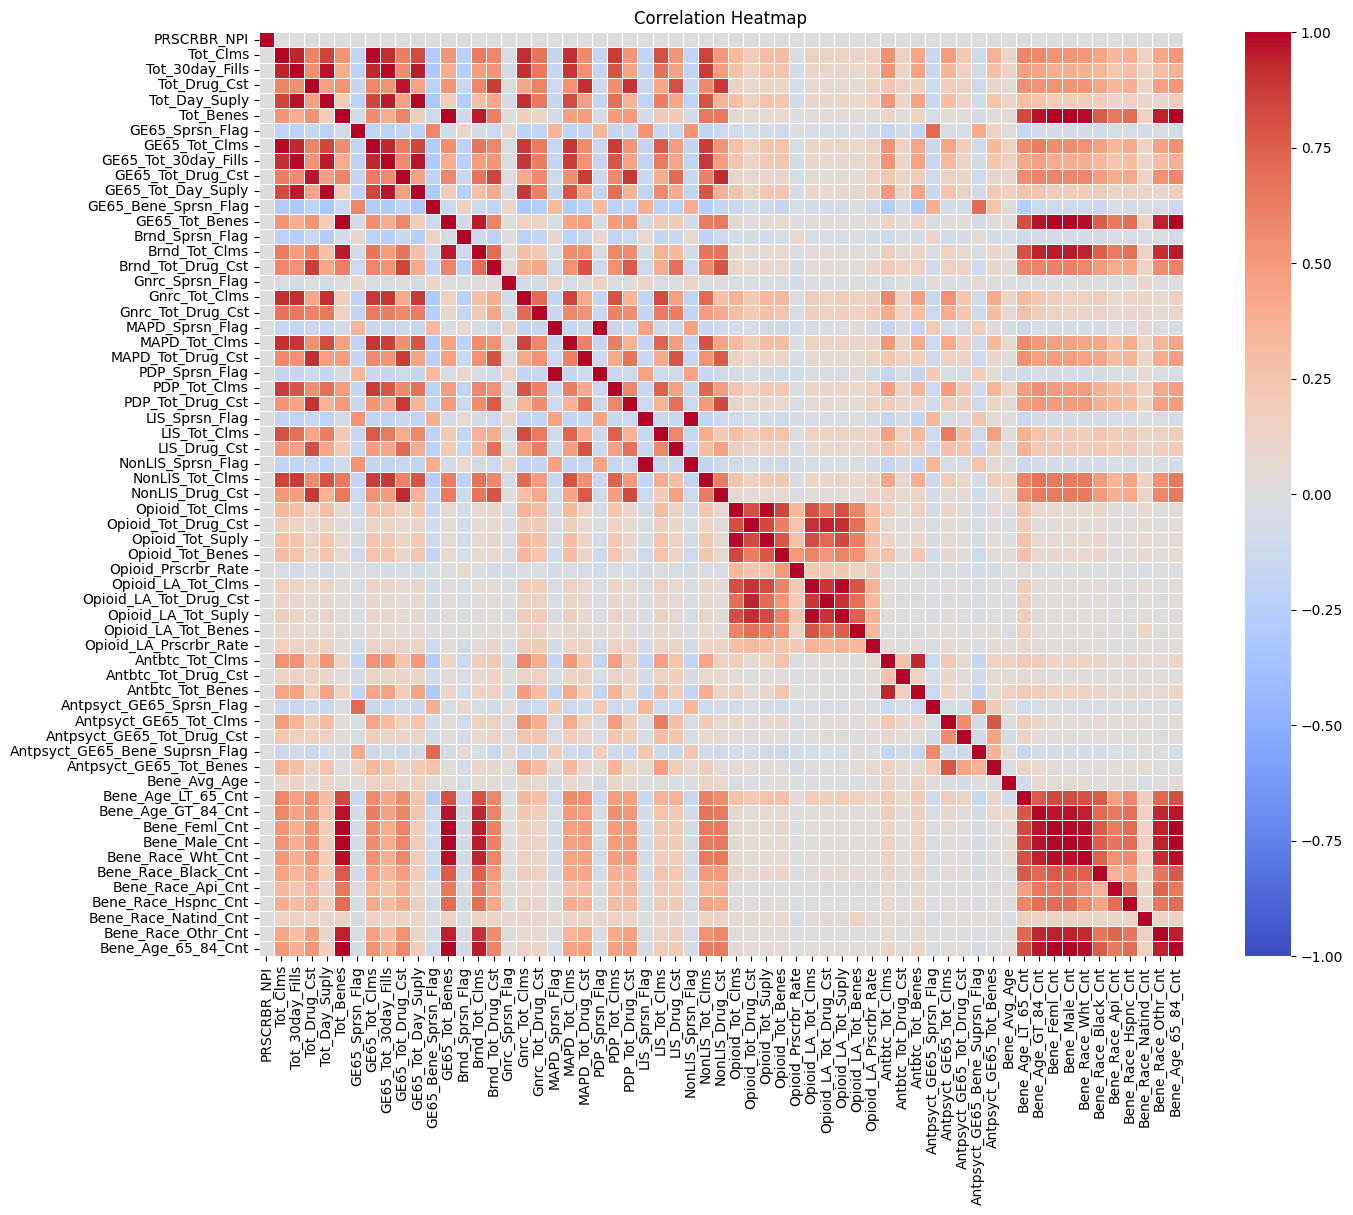

In [30]:
#I am specifying numeric columns with df_op_num.

df_op_num = df_op.select_dtypes(include = 'number')

matrix = df_op_num.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    matrix,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [31]:
#Cost per patient features

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Drug_Cst'] / df_op['Tot_Benes']

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Tot_Drug_Cst'] / df_op['GE65_Tot_Benes']

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Tot_Drug_Cst'] / df_op['Opioid_Tot_Benes']

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Tot_Drug_Cst'] / df_op['Opioid_LA_Tot_Benes']

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Tot_Drug_Cst'] / df_op['Antbtc_Tot_Benes']

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'] / df_op['Antpsyct_GE65_Tot_Benes']

#Fill NA from div/0

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Cst_Per_Bene'].fillna(0)

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Cst_Per_Bene'].fillna(0)

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Cst_Per_Bene'].fillna(0)

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Cst_Per_Bene'].fillna(0)

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Cst_Per_Bene'].fillna(0)

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Cst_Per_Bene'].fillna(0)

## Data Modeling

KPrototype is the model selected because the K-means modeling is not fit for data sets with categorical features.  
KPrototype is able to integrate both numerical and categorical data.  

A resource by Aprilliant (2021) was used to generate this k-prototypes model.  

Aprilliant, A. (2021, January 17). The k-prototype as clustering algorithm for mixed data type(Categorical and numerical). Towards Data Science. https://towardsdatascience.com/the-k-prototype-as-clustering-algorithm-for-mixed-data-type-categorical-and-numerical-fe7c50538ebb/

In [32]:
from kmodes.kprototypes import KPrototypes

In [33]:
# Creating my own copy of the operational data frame (ML).
df_op_ml = df_op.copy()

In [34]:
# Normalizing the opioid and long=acting opioid numerical data.

opioid_norm = df_op_ml.copy()
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,...,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,...,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,...,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,...,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,...,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,...,10.0,0.0,10.0,0.0,49.068846,39.698000,2.353333,0.00000,0.000000,0.0


In [35]:
# Normalizing opioid data to overall total data.

opioid_norm['Opioid_Tot_Clms_norm'] = opioid_norm['Opioid_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_Tot_Suply_norm'] = opioid_norm['Opioid_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_Tot_Benes_norm'] = opioid_norm['Opioid_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Opioid_LA_Tot_Clms_norm'] = opioid_norm['Opioid_LA_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_LA_Tot_Suply_norm'] = opioid_norm['Opioid_LA_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_LA_Tot_Benes_norm'] = opioid_norm['Opioid_LA_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

pd.set_option('display.max_columns', None)
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes,Brnd_Sprsn_Flag,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Sprsn_Flag,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Sprsn_Flag,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Sprsn_Flag,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Sprsn_Flag,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Sprsn_Flag,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Clms,Opioid_Tot_Drug_Cst,Opioid_Tot_Suply,Opioid_Tot_Benes,Opioid_Prscrbr_Rate,Opioid_LA_Tot_Clms,Opioid_LA_Tot_Drug_Cst,Opioid_LA_Tot_Suply,Opioid_LA_Tot_Benes,Opioid_LA_Prscrbr_Rate,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antpsyct_GE65_Sprsn_Flag,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Bene_Suprsn_Flag,Antpsyct_GE65_Tot_Benes,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,GE65_Cst_Per_Bene_norm,Antbtc_Cst_Per_Bene_norm,Antpsyct_GE65_Cst_Per_Bene_norm
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,222,254.46,18399.98,5475,112.0,0,192.0,220.46,15997.83,4769.0,0,96.0,1,10.0,0.00,0,189.0,3170.22,0,91.0,9238.20,0,131.0,9161.78,0,66.0,7243.45,0,156.0,11156.53,13.0,43.68,77.0,13.0,5.855856,0.0,0.00,0.0,0.0,0.000000,42.0,731.76,39.0,1,10.0,0.0,1,10.0,76.196429,16.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0,0.058559,0.002374,0.014064,0.116071,0.020452,0.000000,0.000000,0.000000,0.000000,0.000000,1.014356,0.114210,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,1865,1999.46,62623.40,55983,478.0,0,1017.0,1081.00,36179.85,29714.0,0,290.0,0,55.0,19957.16,0,1810.0,42666.24,0,1314.0,44891.82,0,551.0,17731.58,0,1398.0,50702.42,0,467.0,11920.98,850.0,26878.15,23387.0,358.0,45.576408,65.0,12186.81,1903.0,24.0,7.647059,10.0,0.00,10.0,0,0.0,0.0,0,0.0,66.581590,188.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0,0.455764,0.429203,0.417752,0.748954,0.573070,0.034853,0.194605,0.033992,0.050209,3.875878,0.952270,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,118,119.00,456.67,806,59.0,0,105.0,106.00,413.64,703.0,1,10.0,1,10.0,0.00,0,108.0,383.19,0,46.0,156.89,0,72.0,299.78,0,13.0,31.52,0,105.0,425.15,10.0,0.00,0.0,10.0,0.000000,10.0,0.00,0.0,10.0,0.000000,60.0,266.45,49.0,0,0.0,0.0,1,10.0,72.355932,10.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0,0.084746,0.000000,0.000000,0.169492,0.000000,0.084746,0.000000,0.000000,0.169492,0.000000,5.344069,0.702537,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,162,339.96,19129.03,9260,64.0,0,134.0,274.27,10246.24,7351.0,1,10.0,0,17.0,10459.97,0,145.0,8669.06,0,72.0,12396.49,0,90.0,6732.54,0,31.0,8946.64,0,131.0,10182.39,0.0,0.00,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,0.000000,10.0,0.00,10.0,0,0.0,0.0,1,10.0,69.984375,10.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.428085,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,41,47.10,1275.79,851,26.0,0

In [36]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(df_op_ml.isnull().sum())

PRSCRBR_NPI                       0
Prscrbr_Crdntls                   0
Prscrbr_Ent_Cd                    0
Prscrbr_City                      0
Prscrbr_State_Abrvtn              0
Prscrbr_zip5                      0
Prscrbr_RUCA                      0
Prscrbr_Cntry                     0
Prscrbr_Type                      0
Prscrbr_Type_src                  0
Tot_Clms                          0
Tot_30day_Fills                   0
Tot_Drug_Cst                      0
Tot_Day_Suply                     0
Tot_Benes                         0
GE65_Sprsn_Flag                   0
GE65_Tot_Clms                     0
GE65_Tot_30day_Fills              0
GE65_Tot_Drug_Cst                 0
GE65_Tot_Day_Suply                0
GE65_Bene_Sprsn_Flag              0
GE65_Tot_Benes                    0
Brnd_Sprsn_Flag                   0
Brnd_Tot_Clms                     0
Brnd_Tot_Drug_Cst                 0
Gnrc_Sprsn_Flag                   0
Gnrc_Tot_Clms                     0
Gnrc_Tot_Drug_Cst           

In [37]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(opioid_norm.isnull().sum())

PRSCRBR_NPI                         0
Prscrbr_Crdntls                     0
Prscrbr_Ent_Cd                      0
Prscrbr_City                        0
Prscrbr_State_Abrvtn                0
Prscrbr_zip5                        0
Prscrbr_RUCA                        0
Prscrbr_Cntry                       0
Prscrbr_Type                        0
Prscrbr_Type_src                    0
Tot_Clms                            0
Tot_30day_Fills                     0
Tot_Drug_Cst                        0
Tot_Day_Suply                       0
Tot_Benes                           0
GE65_Sprsn_Flag                     0
GE65_Tot_Clms                       0
GE65_Tot_30day_Fills                0
GE65_Tot_Drug_Cst                   0
GE65_Tot_Day_Suply                  0
GE65_Bene_Sprsn_Flag                0
GE65_Tot_Benes                      0
Brnd_Sprsn_Flag                     0
Brnd_Tot_Clms                       0
Brnd_Tot_Drug_Cst                   0
Gnrc_Sprsn_Flag                     0
Gnrc_Tot_Clm

In [38]:
# Rows that have at least one NaN (ML).

pd.set_option('display.max_columns', None)
nan_rows = opioid_norm[opioid_norm.isnull().any(axis=1)]
print(nan_rows)

         PRSCRBR_NPI  Prscrbr_Crdntls Prscrbr_Ent_Cd    Prscrbr_City  \
67214     1043870702  MSN, APRN, NP-C              I  Salt Lake City   
72543     1053377127               MD              I         Memphis   
101667    1073519666             M.D.              I       Allentown   
134819    1093815599      ARNP, CWOCN              I       Lake City   
144199    1104402080               MD              I         Atlanta   
158677    1114422334          Unknown              I       Northport   
182055    1134198534             M.D.              I       Salisbury   
223011    1164175030             CRNP              I      Pittsburgh   
231066    1164781282          Unknown              I       Las Vegas   
294236    1215251152             M.D.              I        Woodside   
490722    1356507891             O.D.              I      Trussville   
663771    1477991420             M.D.              I        Richmond   
718070    1518953017               MD              I       Louis

In [39]:
# Replace NaN in prdemo with zero, because, upon inspection, the total, opioid, and long-acting opioid drug costs were all zero (ML).

opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'].fillna(0)

In [40]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(opioid_norm.isnull().sum())

PRSCRBR_NPI                        0
Prscrbr_Crdntls                    0
Prscrbr_Ent_Cd                     0
Prscrbr_City                       0
Prscrbr_State_Abrvtn               0
Prscrbr_zip5                       0
Prscrbr_RUCA                       0
Prscrbr_Cntry                      0
Prscrbr_Type                       0
Prscrbr_Type_src                   0
Tot_Clms                           0
Tot_30day_Fills                    0
Tot_Drug_Cst                       0
Tot_Day_Suply                      0
Tot_Benes                          0
GE65_Sprsn_Flag                    0
GE65_Tot_Clms                      0
GE65_Tot_30day_Fills               0
GE65_Tot_Drug_Cst                  0
GE65_Tot_Day_Suply                 0
GE65_Bene_Sprsn_Flag               0
GE65_Tot_Benes                     0
Brnd_Sprsn_Flag                    0
Brnd_Tot_Clms                      0
Brnd_Tot_Drug_Cst                  0
Gnrc_Sprsn_Flag                    0
Gnrc_Tot_Clms                      0
G

In [41]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer opioid-related features.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_opioid = opioid_norm[['Opioid_Prscrbr_Rate', 'Opioid_Tot_Clms_norm', 'Opioid_Tot_Drug_Cst_norm', 'Opioid_Tot_Suply_norm', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm']]
opioid_corr = X_opioid.corr()

opioid_corr

,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm
Opioid_Prscrbr_Rate,1.000000,0.680120,0.819775,0.905669,0.332734,0.633764
Opioid_Tot_Clms_norm,0.680120,1.000000,0.570620,0.628862,0.531241,0.409797
Opioid_Tot_Drug_Cst_norm,0.819775,0.570620,1.000000,0.896502,0.280067,0.803508
Opioid_Tot_Suply_norm,0.905669,0.628862,0.896502,1.000000,0.306562,0.660058
Opioid_Tot_Benes_norm,0.332734,0.531241,0.280067,0.306562,1.000000,0.154802
Opioid_Cst_Per_Bene_norm,0.633764,0.409797,0.803508,0.660058,0.154802,1.000000


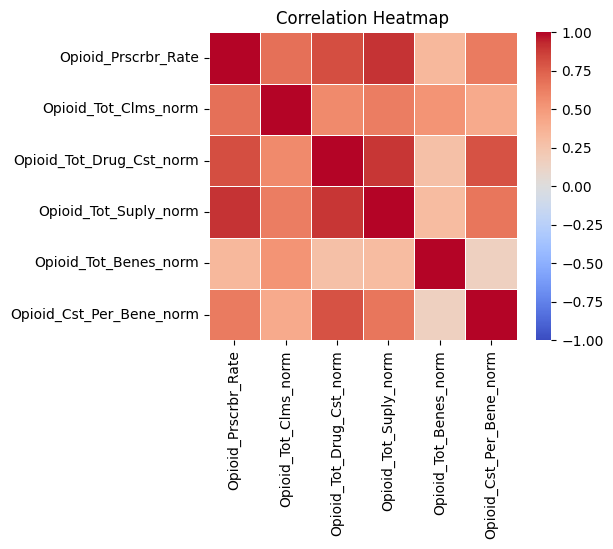

In [42]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [43]:
# Running the Principal Component Reduction on the opioid data.

opioid_pca = PCA(n_components = 6)
opioid_pca_c = opioid_pca.fit_transform(X_opioid)

In [44]:
# Looking at the variability explained by each component in X_opioid.

opioid_pca.explained_variance_ratio_
opioid_ex_vratio = np.cumsum(opioid_pca.explained_variance_ratio_)
opioid_ex_vratio

array([0.99907885, 0.99975153, 0.99991165, 0.99998159, 0.9999967 ,
       1.        ])

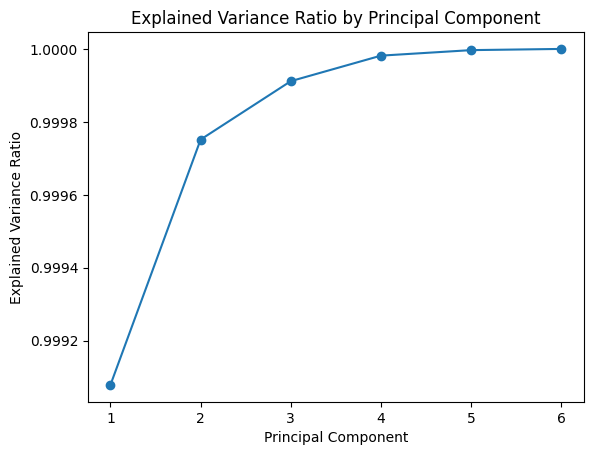

In [45]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_ex_vratio) + 1)
y = opioid_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [46]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_comps = opioid_pca.components_

opioid_comps_df = pd.DataFrame(
    opioid_comps,
    columns=X_opioid.columns,
    index=[f'PC{i+1}' for i in range(opioid_comps.shape[0])]
)

print(opioid_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_Prscrbr_Rate  Opioid_Tot_Clms_norm  Opioid_Tot_Drug_Cst_norm  \
PC1             0.999831              0.008778                  0.006491   
PC2            -0.009974              0.179660                  0.000089   
PC3            -0.012285              0.012164                  0.251445   
PC4            -0.007106              0.983274                  0.016292   
PC5            -0.005726             -0.025796                  0.786110   
PC6            -0.002157             -0.001997                 -0.564357   

     Opioid_Tot_Suply_norm  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  
PC1               0.006006               0.009021                  0.010084  
PC2               0.000979               0.982549                 -0.047110  
PC3               0.071097               0.043783                  0.964108  
PC4               0.015412              -0.180346                 -0.009692  
PC5               0.566277              -0.007780                 -0.246176  

In [47]:
# From the ratio plot, the top 2 variables explain 89% of the variance in the data.
# From the table above, Opioid_Tot_Benes_norm (PC1 value = 0.89, 63% of variance) and Opioid_Cst_Per_Bene_norm (PC2 value = 0.71, 89% of variance) will be those two variables.
# Should it become necessary later on in the analysis, these two varaibles can be used to represent the opioid data.

In [48]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer long-acting opioid-related features.

X_opioid_LA = opioid_norm[['Opioid_LA_Prscrbr_Rate', 'Opioid_LA_Tot_Clms_norm', 'Opioid_LA_Tot_Drug_Cst_norm', 'Opioid_LA_Tot_Suply_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
opioid_LA_corr = X_opioid_LA.corr()

opioid_LA_corr

,Opioid_LA_Prscrbr_Rate,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
Opioid_LA_Prscrbr_Rate,1.000000,0.017264,0.527906,0.599299,-0.030617,0.427334
Opioid_LA_Tot_Clms_norm,0.017264,1.000000,0.071138,0.085200,0.458601,0.020411
Opioid_LA_Tot_Drug_Cst_norm,0.527906,0.071138,1.000000,0.866272,0.015166,0.712107
Opioid_LA_Tot_Suply_norm,0.599299,0.085200,0.866272,1.000000,0.024758,0.486035
Opioid_LA_Tot_Benes_norm,-0.030617,0.458601,0.015166,0.024758,1.000000,-0.026707
Opioid_LA_Cst_Per_Bene_norm,0.427334,0.020411,0.712107,0.486035,-0.026707,1.000000


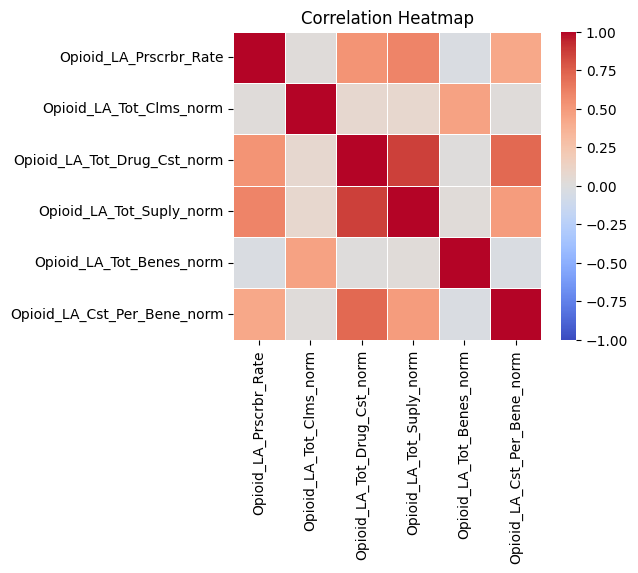

In [49]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_LA_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [50]:
# Running the Principal Component Reduction on the opioid data.

opioid_LA_pca = PCA(n_components = 6)
opioid_LA_pca_c = opioid_LA_pca.fit_transform(X_opioid_LA)

In [51]:
# Looking at the variability explained by each component in X_opioid.

opioid_LA_pca.explained_variance_ratio_
opioid_LA_ex_vratio = np.cumsum(opioid_LA_pca.explained_variance_ratio_)
opioid_LA_ex_vratio

array([0.99107075, 0.99545989, 0.99955549, 0.99996474, 0.99999873,
       1.        ])

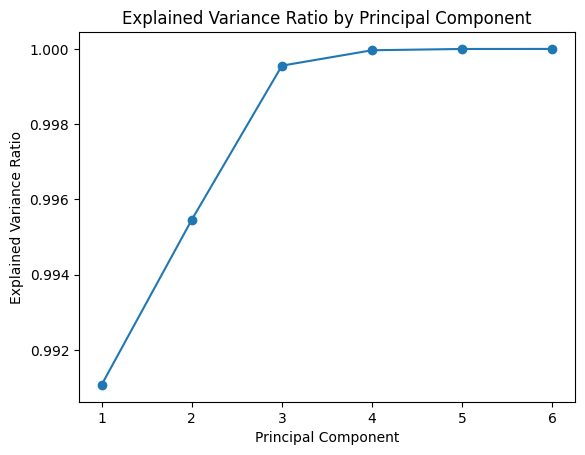

In [52]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_LA_ex_vratio) + 1)
y = opioid_LA_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [53]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_LA_comps = opioid_LA_pca.components_

opioid_LA_comps_df = pd.DataFrame(
    opioid_LA_comps,
    columns=X_opioid_LA.columns,
    index=[f'PC{i+1}' for i in range(opioid_LA_comps.shape[0])]
)

print(opioid_LA_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_LA_Prscrbr_Rate  Opioid_LA_Tot_Clms_norm  \
PC1                0.999490                 0.000401   
PC2               -0.031505                -0.027626   
PC3               -0.004365                 0.182817   
PC4               -0.000535                 0.982556   
PC5               -0.002614                -0.019843   
PC6               -0.000550                -0.001987   

     Opioid_LA_Tot_Drug_Cst_norm  Opioid_LA_Tot_Suply_norm  \
PC1                     0.004521                  0.001677   
PC2                     0.067246                  0.010214   
PC3                     0.018983                  0.004258   
PC4                     0.016879                  0.007667   
PC5                     0.948150                  0.309470   
PC6                    -0.309555                  0.950812   

     Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
PC1                 -0.001951                     0.031493  
PC2                 -0.192091                     

In [54]:
# From the ratio plot, the top 2 variables explain 95% of the variance in the data.
# From the table above, Opioid_LA_Cst_Per_Bene_norm (PC1 value = 0.99, 54% of variance) and Opioid_LA_Tot_Benes_norm (PC2 value = 0.98, 95% of variance) will be those two variables.
# Should it become necessary later on in the analysis, these two varaibles can be used to represent the long-acting opioid data.

### Prescriber Demographic Information

In [55]:
# Creating subset of the data: prescriber demographics + opioid data.

prdemo = opioid_norm[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm']]
prdemo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,222,254.46,18399.98,5475,112.0,164.285536,0.116071,0.020452,0.000000,0.000000
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,1865,1999.46,62623.40,55983,478.0,131.011297,0.748954,0.573070,3.875878,0.050209
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,118,119.00,456.67,806,59.0,7.740169,0.169492,0.000000,0.000000,0.169492
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,162,339.96,19129.03,9260,64.0,298.891094,0.000000,0.000000,0.000000,0.000000
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,41,47.10,1275.79,851,26.0,49.068846,0.576923,0.047960,0.000000,0.000000


In [56]:
# Checking data types in prdemo.

print(prdemo.dtypes)

Prscrbr_Crdntls                 object
Prscrbr_Ent_Cd                  object
Prscrbr_City                    object
Prscrbr_State_Abrvtn            object
Prscrbr_RUCA                    object
Prscrbr_Type                    object
Prscrbr_Type_src                object
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


In [57]:
# Converting objects to strings.

prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)
print(prdemo.dtypes)

Prscrbr_Crdntls                 object
Prscrbr_Ent_Cd                  object
Prscrbr_City                    object
Prscrbr_State_Abrvtn            object
Prscrbr_RUCA                    object
Prscrbr_Type                    object
Prscrbr_Type_src                object
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/488052295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)


In [58]:
# Standardizing numeric data to zscore.

prdemo_num = prdemo[['Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
prdemo_numz = pd.DataFrame(stats.zscore(prdemo_num, nan_policy = 'omit'), columns = prdemo_num.columns)
prdemo_numz.head()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.313619,-0.364287,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874
1,0.229793,-0.026236,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701
2,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.333463,-0.347723,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874


In [59]:
# Comparing against mean values and standard deviations in each column in prdemo_num.

print(prdemo_num.describe())

           Tot_Clms  Tot_30day_Fills  Tot_Drug_Cst  Tot_Day_Suply  \
count  1.380665e+06     1.380665e+06  1.380665e+06   1.380665e+06   
mean   1.170223e+03     2.134888e+03  1.996484e+05   5.963938e+04   
std    3.023489e+03     5.161946e+03  6.444544e+05   1.430670e+05   
min    1.100000e+01     1.100000e+01  0.000000e+00   1.100000e+01   
25%    5.900000e+01     7.200000e+01  1.849030e+03   1.073000e+03   
50%    2.090000e+02     2.661700e+02  1.339771e+04   5.212000e+03   
75%    9.260000e+02     1.459090e+03  1.389983e+05   3.957600e+04   
max    6.662510e+05     6.673819e+05  1.602919e+08   7.288659e+06   

          Tot_Benes  Tot_Cst_Per_Bene  Opioid_Tot_Benes_norm  \
count  1.380665e+06      1.380665e+06           1.380665e+06   
mean   1.607810e+02      1.022297e+03           2.420434e-01   
std    8.927201e+02      4.124140e+03           3.307473e-01   
min    1.000000e+01      0.000000e+00           0.000000e+00   
25%    2.500000e+01      3.776759e+01           0.000000e+

In [60]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

#prdemo_f = pd.concat([prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']], prdemo_numz], axis = 1)
#prdemo_f.head()

In [61]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

prdemo_cat = prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']]

prdemo_f = pd.concat([prdemo_cat, prdemo_numz], axis = 1)
prdemo_f.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.313619,-0.364287,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.229793,-0.026236,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.333463,-0.347723,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874


In [62]:
# Need indices for categorical data.

#prdemo_cat_cols = prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns.tolist()
#print(prdemo_cat_cols)

#prdemo_catidx = [prdemo_f.columns.get_loc(col) for col in prdemo_cat_cols]
#print(prdemo_catidx)

In [63]:
# Need indices for categorical data.

prdemo_cat_col_pos = [prdemo_f.columns.get_loc(col) for col in list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)]
print('Categorical columns: {}'.format(list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)))
print('Categorical columns position: {}'.format(prdemo_cat_col_pos))

Categorical columns: ['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']
Categorical columns position: [0, 1, 2, 3, 4, 5, 6]


In [64]:
# Check for null values per column. I got an error when trying to run the kprototypes model (ML).
print(prdemo_f.isnull().sum())

Prscrbr_Crdntls                0
Prscrbr_Ent_Cd                 0
Prscrbr_City                   0
Prscrbr_State_Abrvtn           0
Prscrbr_RUCA                   0
Prscrbr_Type                   0
Prscrbr_Type_src               0
Tot_Clms                       0
Tot_30day_Fills                0
Tot_Drug_Cst                   0
Tot_Day_Suply                  0
Tot_Benes                      0
Tot_Cst_Per_Bene               0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [65]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

prdemo_f_10 = prdemo_f.sample(frac = 0.01, random_state = 0)
prdemo_f_10.describe()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000
mean,-0.003549,0.001208,-0.004853,0.004180,-0.003278,-0.013704,-0.010306,-0.009119,-0.007804,-0.002240
std,0.854274,0.962932,0.827906,1.005553,0.253696,0.830751,0.997016,0.966796,0.995735,1.117683
min,-0.383406,-0.411451,-0.309780,-0.416787,-0.168901,-0.247719,-0.731808,-0.333759,-0.541490,-0.119874
25%,-0.367530,-0.399443,-0.306972,-0.409640,-0.150978,-0.238570,-0.731808,-0.333759,-0.541490,-0.119874
50%,-0.317257,-0.361948,-0.289181,-0.380083,-0.096090,-0.185788,-0.479284,-0.333759,-0.541490,-0.119874
75%,-0.081602,-0.130150,-0.095276,-0.143575,0.050653,-0.033522,0.233319,-0.209533,-0.080604,-0.119874
max,12.721987,13.494610,17.874720,14.154934,10.928646,57.635468,2.291650,14.339094,2.592535,50.093505


In [66]:
# Remove opioid data from prdemo_f.

prdemo_fo_10 = prdemo_f_10[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene']]
prdemo_fo_10.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene
941935,MD,I,Brooklyn,NY,1.0,Family Practice,NPPES-Specialty,0.217556,-0.007956,0.799070,0.015549,-0.063605,1.418230
123147,MD,I,Kansas City,KS,1.0,Urology,Claim-Specialty,0.040277,0.047839,0.224983,0.048122,0.234361,-0.022026
529198,PA-C,I,Chicago,IL,1.0,Physician Assistant,Claim-Specialty,-0.248131,-0.326406,-0.304351,-0.379804,0.094340,-0.244410
28890,MD,I,Lynn,MA,1.0,Cardiology,Claim-Specialty,0.643885,0.746378,0.533969,0.810429,0.470718,-0.020945
804529,DMD,I,Miami,FL,1.0,Dentist,NPPES-Specialty,-0.318249,-0.373287,-0.306968,-0.402765,-0.032240,-0.244536


In [67]:
# Convert the data frame to a matrix.

prdemo_fmat = prdemo_fo_10.to_numpy()

In [68]:
from plotnine import *
import plotnine as p9

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


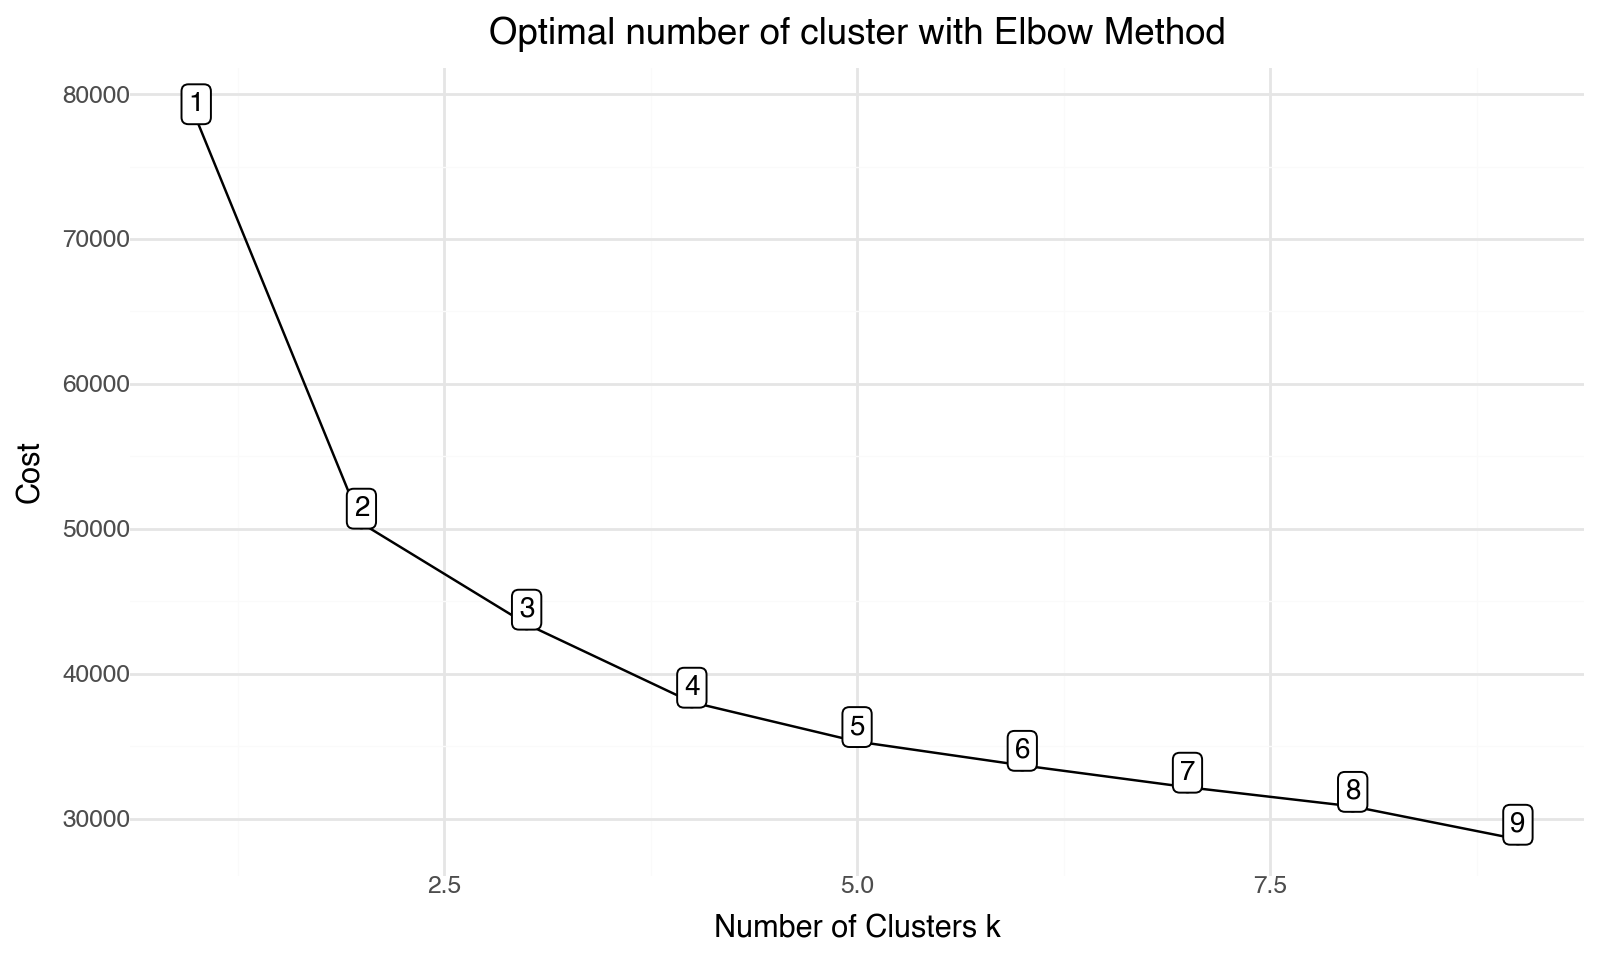

In [69]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)
        cost.append(kprototype_prdemo.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
prdemo_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = prdemo_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [70]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([0, 2, 2, ..., 2, 2, 2], dtype=uint16)

In [71]:
# Cluster centorid

kprototype_prdemo.cluster_centroids_

array([['0.8830036053521266', '1.0285060820950107', '1.0454657989596776',
        '1.0818252872137497', '0.27871728235184506', '0.686837280106868',
        'MD', 'I', 'Brooklyn', 'CA', '1.0', 'Family Practice',
        'Claim-Specialty'],
       ['3.500946109914813', '4.06846366175325', '1.87976782705892',
        '4.233719217416248', '0.6729357652353586', '0.23473103623390304',
        'M.D.', 'I', 'Miami', 'FL', '1.0', 'Family Practice',
        'Claim-Specialty'],
       ['-0.26631780551819356', '-0.3035265943546647',
        '-0.227713210233517', '-0.3140440858552528',
        '-0.06975374836004199', '-0.12300171273472787', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty']],
      dtype='<U32')

In [72]:
# Check the iteration of the clusters created

kprototype_prdemo.n_iter_

9

In [73]:
# Check the cost of the clusters created

kprototype_prdemo.cost_

np.float64(43427.90039098145)

In [74]:
# Add the clusters to the prdemo_f_10 dataframe.

prdemo_f_10['Cluster Labels'] = kprototype_prdemo.labels_
prdemo_f_10['Segment'] = prdemo_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].astype('category')
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

prdemo_f_10.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,MD,I,Brooklyn,NY,1.0,Family Practice,NPPES-Specialty,0.217556,-0.007956,0.799070,0.015549,-0.063605,1.418230,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1
123147,MD,I,Kansas City,KS,1.0,Urology,Claim-Specialty,0.040277,0.047839,0.224983,0.048122,0.234361,-0.022026,-0.650093,-0.333759,-0.456786,-0.119874,2,Cluster 3
529198,PA-C,I,Chicago,IL,1.0,Physician Assistant,Claim-Specialty,-0.248131,-0.326406,-0.304351,-0.379804,0.094340,-0.244410,0.625663,3.217818,-0.413570,-0.119874,2,Cluster 3
28890,MD,I,Lynn,MA,1.0,Cardiology,Claim-Specialty,0.643885,0.746378,0.533969,0.810429,0.470718,-0.020945,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1
804529,DMD,I,Miami,FL,1.0,Dentist,NPPES-Specialty,-0.318249,-0.373287,-0.306968,-0.402765,-0.032240,-0.244536,-0.731808,-0.333759,-0.541490,-0.119874,2,Cluster 3
36793,Unknown,I,Patchogue,NY,1.0,Hospitalist,Claim-Specialty,-0.381421,-0.410289,-0.308498,-0.414347,-0.168901,-0.227626,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 3
1370028,Unknown,I,San Diego,CA,1.0,Neurology,Claim-Specialty,-0.204143,-0.185288,-0.017250,-0.172551,0.043932,-0.019310,-0.731808,-0.333759,-0.541490,-0.119874,2,Cluster 3
1010928,M.D.,I,Crestview Hills,KY,1.0,Ophthalmology,Claim-Specialty,-0.254085,-0.335149,-0.297793,-0.392896,-0.001995,-0.236086,1.226784,0.300534,-0.541490,-0.119874,2,Cluster 3
1253327,MD,I,Ponca City,OK,4.0,Obstetrics & Gynecology,NPPES-Specialty,-0.370176,-0.390002,-0.304941,-0.392567,-0.168901,-0.172034,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 3
227991,M.D.,I,Canaan,CT,10.0,Internal Medicine,NPPES-Specialty,-0.364884,-0.397890,-0.307510,-0.401612,-0.168901,-0.212178,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 3


In [75]:
# Cluster interpretation

prdemo_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/3558481314.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1662,MD,I,Brooklyn,CA,1.0,Family Practice,Claim-Specialty,0.883004,1.028506,1.045466,1.081825,0.278717,0.686837,-0.505079,-0.041812,-0.458446,0.121808
1,Cluster 2,456,M.D.,I,Miami,FL,1.0,Family Practice,Claim-Specialty,3.500946,4.068464,1.879768,4.233719,0.672936,0.234731,-0.479961,-0.016076,-0.509084,0.231757
2,Cluster 3,11689,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.266318,-0.303527,-0.227713,-0.314044,-0.069754,-0.123002,0.078365,-0.004200,0.075826,-0.029006


In [76]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, the model was adjusted for 2 clusters, shown above.

In [77]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo2 = KPrototypes(n_jobs = -1, n_clusters = 2, init = 'Huang', random_state = 0)
kprototype_prdemo2.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([1, 1, 1, ..., 1, 1, 1], dtype=uint16)

In [78]:
# Cluster centorid

kprototype_prdemo2.cluster_centroids_

array([['2.265706371878544', '2.67465261721519', '1.56777942135264',
        '2.795615181789207', '0.5126510068743648', '0.4111734067855415',
        'M.D.', 'I', 'Brooklyn', 'FL', '1.0', 'Family Practice',
        'Claim-Specialty'],
       ['-0.20212706282631174', '-0.23273982994143086',
        '-0.14247041308542077', '-0.2400929581000925',
        '-0.0484262760713495', '-0.05088372424658946', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty']],
      dtype='<U32')

In [79]:
# Check the iteration of the clusters created

kprototype_prdemo2.n_iter_

9

In [80]:
# Check the cost of the clusters created

kprototype_prdemo2.cost_

np.float64(50394.7109098404)

In [81]:
# Add the clusters to the prdemo_f_10 dataframe.
# Adjust map based on k clusters.
# If this doesn't work, then try into prdemo_fo_10 and then concatenate with the opioid data points.

prdemo_f_102 = prdemo_f_10.copy()

prdemo_f_102['Cluster Labels'] = kprototype_prdemo2.labels_
prdemo_f_102['Segment'] = prdemo_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
prdemo_f_102['Segment'] = prdemo_f_102['Segment'].astype('category')
prdemo_f_102['Segment'] = prdemo_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

prdemo_f_102.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Cluster Labels
941935,MD,I,Brooklyn,NY,1.0,Family Practice,NPPES-Specialty,0.217556,-0.007956,0.799070,0.015549,-0.063605,1.418230,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 2,1
123147,MD,I,Kansas City,KS,1.0,Urology,Claim-Specialty,0.040277,0.047839,0.224983,0.048122,0.234361,-0.022026,-0.650093,-0.333759,-0.456786,-0.119874,2,Cluster 2,1
529198,PA-C,I,Chicago,IL,1.0,Physician Assistant,Claim-Specialty,-0.248131,-0.326406,-0.304351,-0.379804,0.094340,-0.244410,0.625663,3.217818,-0.413570,-0.119874,2,Cluster 2,1
28890,MD,I,Lynn,MA,1.0,Cardiology,Claim-Specialty,0.643885,0.746378,0.533969,0.810429,0.470718,-0.020945,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 2,1
804529,DMD,I,Miami,FL,1.0,Dentist,NPPES-Specialty,-0.318249,-0.373287,-0.306968,-0.402765,-0.032240,-0.244536,-0.731808,-0.333759,-0.541490,-0.119874,2,Cluster 2,1
36793,Unknown,I,Patchogue,NY,1.0,Hospitalist,Claim-Specialty,-0.381421,-0.410289,-0.308498,-0.414347,-0.168901,-0.227626,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 2,1
1370028,Unknown,I,San Diego,CA,1.0,Neurology,Claim-Specialty,-0.204143,-0.185288,-0.017250,-0.172551,0.043932,-0.019310,-0.731808,-0.333759,-0.541490,-0.119874,2,Cluster 2,1
1010928,M.D.,I,Crestview Hills,KY,1.0,Ophthalmology,Claim-Specialty,-0.254085,-0.335149,-0.297793,-0.392896,-0.001995,-0.236086,1.226784,0.300534,-0.541490,-0.119874,2,Cluster 2,1
1253327,MD,I,Ponca City,OK,4.0,Obstetrics & Gynecology,NPPES-Specialty,-0.370176,-0.390002,-0.304941,-0.392567,-0.168901,-0.172034,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 2,1
227991,M.D.,I,Canaan,CT,10.0,Internal Medicine,NPPES-Specialty,-0.364884,-0.397890,-0.307510,-0.401612,-0.168901,-0.212178,2.291650,-0.333759,2.592535,-0.119874,2,Cluster 2,1


In [82]:
# Cluster interpretation

prdemo_summary = prdemo_f_102.groupby('Segment', observed=False).agg(
    Total=('Segment', 'count'),
    Prscrbr_Crdntls=('Prscrbr_Crdntls', lambda x: x.value_counts().index[0]),
    Prscrbr_Ent_Cd=('Prscrbr_Ent_Cd', lambda x: x.value_counts().index[0]),
    Prscrbr_City=('Prscrbr_City', lambda x: x.value_counts().index[0]),
    Prscrbr_State_Abrvtn=('Prscrbr_State_Abrvtn', lambda x: x.value_counts().index[0]),
    Prscrbr_RUCA=('Prscrbr_RUCA', lambda x: x.value_counts().index[0]),
    Prscrbr_Type=('Prscrbr_Type', lambda x: x.value_counts().index[0]),
    Prscrbr_Type_src=('Prscrbr_Type_src', lambda x: x.value_counts().index[0]),
    Tot_Clms=('Tot_Clms', 'mean'),
    Tot_30day_Fills=('Tot_30day_Fills', 'mean'),
    Tot_Drug_Cst=('Tot_Drug_Cst', 'mean'),
    Tot_Day_Suply=('Tot_Day_Suply', 'mean'),
    Tot_Benes=('Tot_Benes', 'mean'),
    Tot_Cst_Per_Bene=('Tot_Cst_Per_Bene', 'mean'),
    Opioid_Tot_Benes_norm=('Opioid_Tot_Benes_norm', 'mean'),
    Opioid_Cst_Per_Bene_norm=('Opioid_Cst_Per_Bene_norm', 'mean'),
    Opioid_LA_Tot_Benes_norm=('Opioid_LA_Tot_Benes_norm', 'mean'),
    Opioid_LA_Cst_Per_Bene_norm=('Opioid_LA_Cst_Per_Bene_norm', 'mean')
).reset_index()

prdemo_summary

,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1111,M.D.,I,Brooklyn,FL,1.0,Family Practice,Claim-Specialty,2.265706,2.674653,1.567779,2.795615,0.512651,0.411173,-0.501452,-0.009258,-0.498725,0.203233
1,Cluster 2,12696,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.202127,-0.232740,-0.142470,-0.240093,-0.048426,-0.050884,0.032673,-0.009107,0.035155,-0.020221


### Beneficiaries Age 65+

In [83]:
# Creating subset of the data: beneficiaries aged 65+ + opioid data.

ge65 = opioid_norm[['GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Tot_Benes', 'GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65.head()

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,192.0,220.46,15997.83,4769.0,96.0,166.644062,0.116071,0.020452,0.000000,0.000000
1,1017.0,1081.00,36179.85,29714.0,290.0,124.758103,0.748954,0.573070,0.050209,3.875878
2,105.0,106.00,413.64,703.0,10.0,41.364000,0.169492,0.000000,0.169492,0.000000
3,134.0,274.27,10246.24,7351.0,10.0,1024.624000,0.000000,0.000000,0.000000,0.000000
4,20.0,25.00,396.98,329.0,10.0,39.698000,0.576923,0.047960,0.000000,0.000000


In [84]:
# Checking data types in ge65.

print(ge65.dtypes)

GE65_Tot_Clms                  float64
GE65_Tot_30day_Fills           float64
GE65_Tot_Drug_Cst              float64
GE65_Tot_Day_Suply             float64
GE65_Tot_Benes                 float64
GE65_Cst_Per_Bene              float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [85]:
# Check for null values per column (ML).
print(ge65.isnull().sum())

GE65_Tot_Clms                  0
GE65_Tot_30day_Fills           0
GE65_Tot_Drug_Cst              0
GE65_Tot_Day_Suply             0
GE65_Tot_Benes                 0
GE65_Cst_Per_Bene              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [86]:
# Preparing for a Principal Component Reduction.

X_ge65 = ge65.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
ge65_corr = X_ge65.corr()

ge65_corr

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene
GE65_Tot_Clms,1.000000,0.937499,0.635519,0.836857,0.551410,0.073864
GE65_Tot_30day_Fills,0.937499,1.000000,0.569913,0.967070,0.398090,0.073933
GE65_Tot_Drug_Cst,0.635519,0.569913,1.000000,0.463682,0.597512,0.335666
GE65_Tot_Day_Suply,0.836857,0.967070,0.463682,1.000000,0.179612,0.077046
GE65_Tot_Benes,0.551410,0.398090,0.597512,0.179612,1.000000,-0.008732
GE65_Cst_Per_Bene,0.073864,0.073933,0.335666,0.077046,-0.008732,1.000000


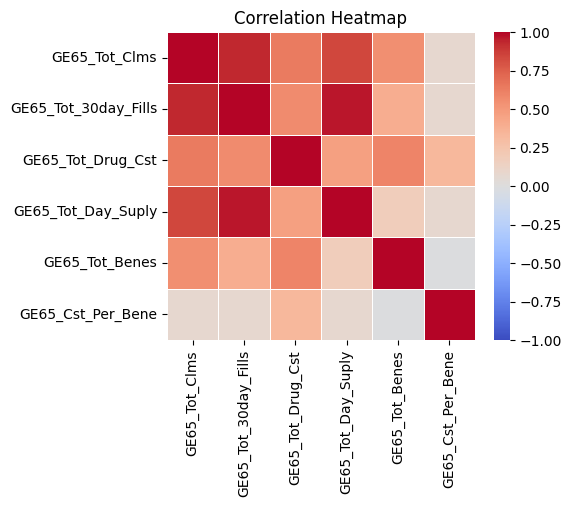

In [87]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    ge65_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [88]:
# Running the Principal Component Reduction.

ge65_pca = PCA(n_components = 6)
ge65_pca_c = ge65_pca.fit_transform(X_ge65)

In [89]:
# Looking at the variability explained by each component in ge65.

ge65_pca.explained_variance_ratio_
ge65_ex_vratio = np.cumsum(ge65_pca.explained_variance_ratio_)
ge65_ex_vratio

array([0.9567422 , 0.99929067, 0.99999055, 0.99999897, 0.99999987,
       1.        ])

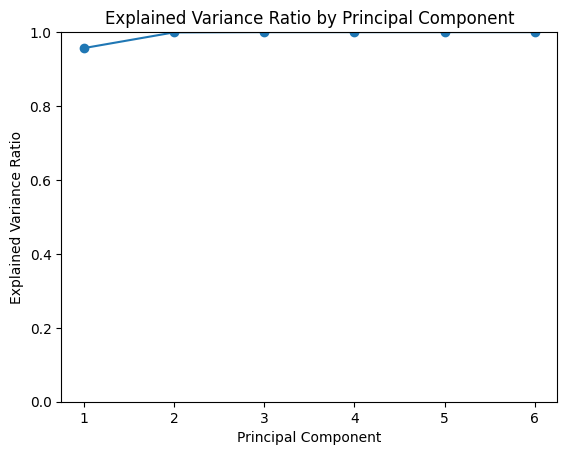

In [90]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(ge65_ex_vratio) + 1)
y = ge65_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [91]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

ge65_comps = ge65_pca.components_

ge65_comps_df = pd.DataFrame(
    ge65_comps,
    columns=X_ge65.columns,
    index=[f'PC{i+1}' for i in range(ge65_comps.shape[0])]
)

print(ge65_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     GE65_Tot_Clms  GE65_Tot_30day_Fills  GE65_Tot_Drug_Cst  \
PC1       0.003210              0.005093           0.993160   
PC2       0.013957              0.031928          -0.116208   
PC3      -0.016632             -0.015795          -0.011057   
PC4       0.742420              0.588538          -0.002579   
PC5      -0.584426              0.338999          -0.000377   
PC6      -0.326768              0.733081           0.000168   

     GE65_Tot_Day_Suply  GE65_Tot_Benes  GE65_Cst_Per_Bene  
PC1            0.116205        0.000943           0.009620  
PC2            0.992521       -0.000932          -0.013492  
PC3            0.013021       -0.013820           0.999495  
PC4           -0.029017        0.317633           0.026396  
PC5           -0.001959        0.737216           0.005847  
PC6           -0.019553       -0.596179          -0.001840  


In [92]:
# From the ratio plot, the top variable explains 99% of the variance in the data.
# From the table above, GE65_Tot_Drug_Cst (PC1 value = 0.99) will be that variable.

In [93]:
# Standardizing numeric data to zscore.

ge65_num = ge65[['GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65_numz = pd.DataFrame(stats.zscore(ge65_num, nan_policy = 'omit'), columns = ge65_num.columns)
ge65_numz.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.213088,1.532623,2.616815,-0.384133,10.377701
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874


In [94]:
# Comparing against mean values and standard deviations in each column in ge65_num.

print(ge65_num.describe())

       GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  \
count       1.380665e+06           1.380665e+06              1.380665e+06   
mean        1.497340e+05           2.420434e-01              6.482383e-02   
std         5.328972e+05           3.307473e-01              1.942233e-01   
min         0.000000e+00           0.000000e+00              0.000000e+00   
25%         7.960000e+01           0.000000e+00              0.000000e+00   
50%         5.952770e+03           8.695652e-02              0.000000e+00   
75%         9.029066e+04           3.333333e-01              2.701004e-02   
max         1.546347e+08           1.000000e+00              1.535182e+01   

       Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
count              1.380665e+06                 1.380665e+06  
mean               1.727777e-01                 4.425943e-02  
std                3.190786e-01                 3.692166e-01  
min                0.000000e+00                 0.0000

In [95]:
# The ge65-num data frame serves as the final data set because this subset does not include categorical data.

ge65_f = ge65_numz.copy()
ge65_f.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.213088,1.532623,2.616815,-0.384133,10.377701
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874


In [96]:
# Check for null values per column.
print(ge65_f.isnull().sum())

GE65_Tot_Drug_Cst              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [97]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

ge65_f_10 = ge65_f.sample(frac = 0.01, random_state = 0)
ge65_f_10.describe()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000
mean,-0.002375,-0.010306,-0.009119,-0.007804,-0.002240
std,0.805243,0.997016,0.966796,0.995735,1.117683
min,-0.280981,-0.731808,-0.333759,-0.541490,-0.119874
25%,-0.280866,-0.731808,-0.333759,-0.541490,-0.119874
50%,-0.269514,-0.479284,-0.333759,-0.541490,-0.119874
75%,-0.110770,0.233319,-0.209533,-0.080604,-0.119874
max,19.020696,2.291650,14.339094,2.592535,50.093505


In [98]:
# Remove opioid data from prdemo_f.

ge65_fo_10 = ge65_f_10[['GE65_Tot_Drug_Cst']]
ge65_fo_10.head()

,GE65_Tot_Drug_Cst
941935,0.448933
123147,0.220474
529198,-0.274894
28890,0.697972
804529,-0.278024


In [99]:
# Convert the data frame to a matrix.

ge65_fmat = ge65_fo_10.to_numpy()

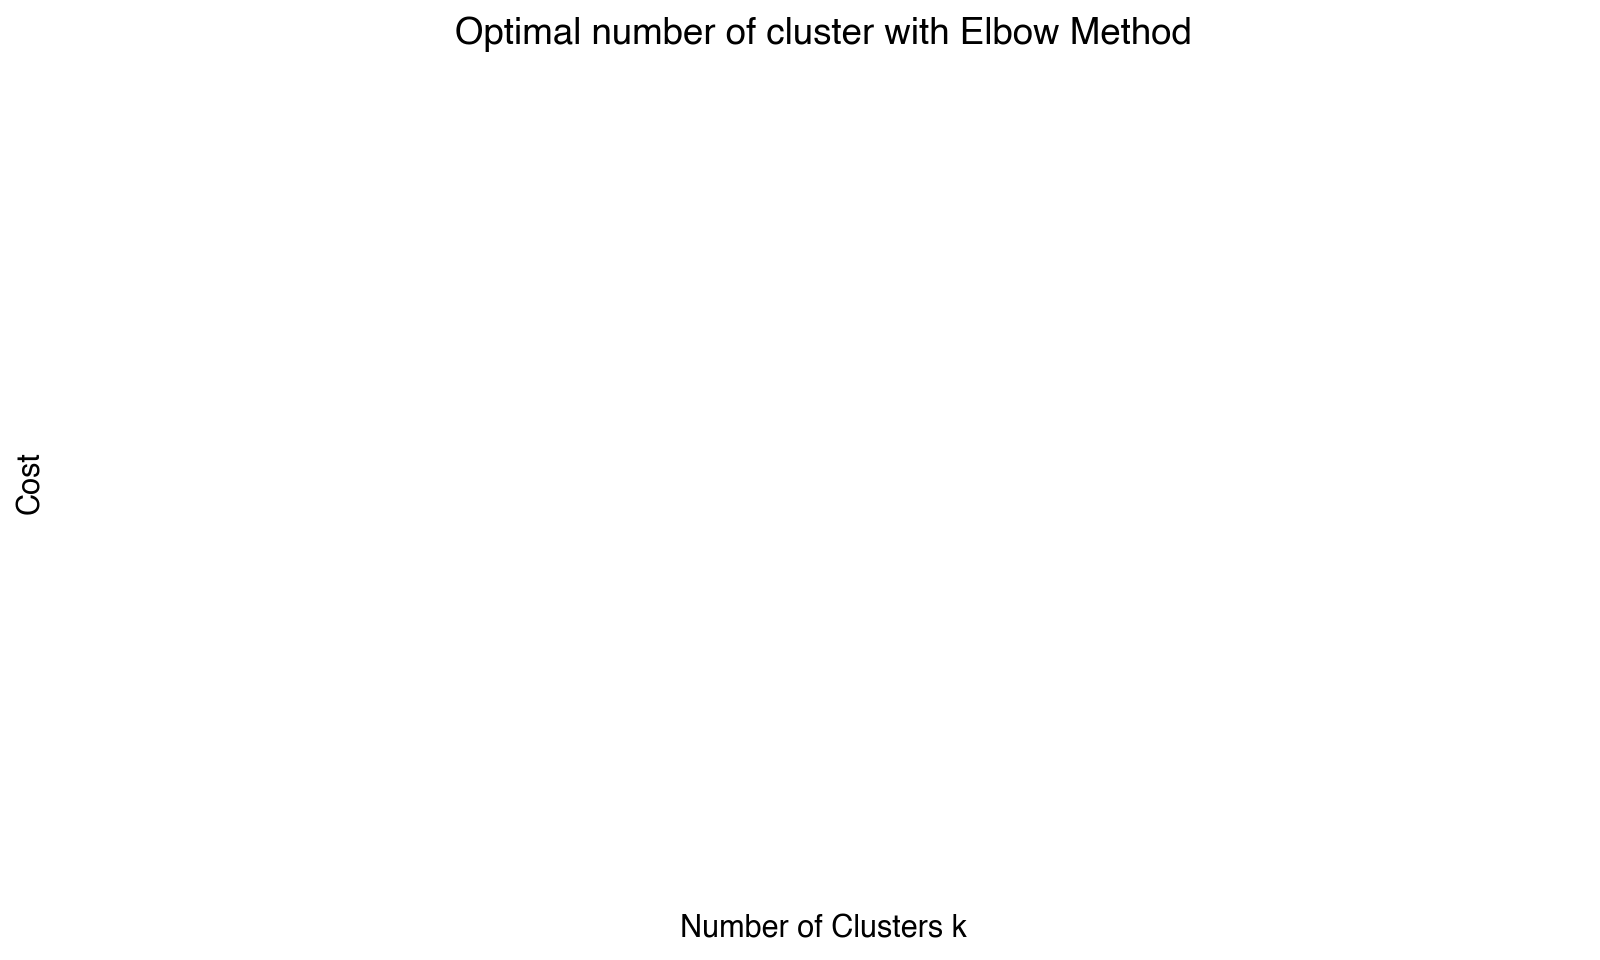

In [100]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_ge65.fit_predict(ge65_fmat)
        cost.append(kprototype_ge65.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
ge65_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = ge65_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [101]:
# Without a graph above, I turned to ChatGPT to help me graph it differently.

costs = []

K = range(1, 10)

for k in K:
    kprototype_ge65 = KPrototypes(n_clusters=k, init='Cao', random_state=42)
    clusters = kprototype_ge65.fit_predict(ge65_fmat)
    costs.append(kprototype_ge65.cost_)

# Plot
plt.plot(K, costs, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Cost')
plt.title('Elbow Method')
plt.show()

NotImplementedError: No categorical data selected, effectively doing k-means. Present a list of categorical columns, or use scikit-learn's KMeans instead.

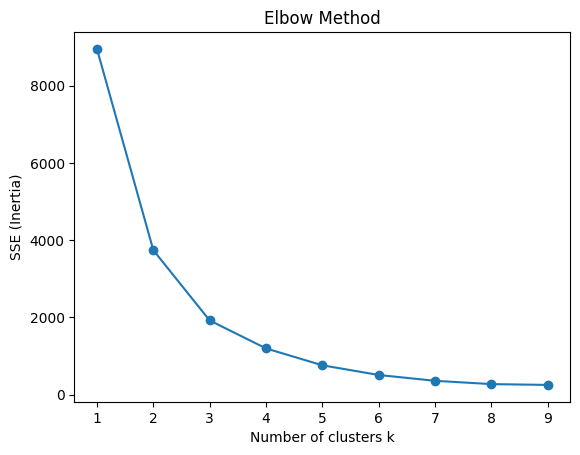

In [102]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_ge65 = KMeans(n_clusters=k, random_state=42).fit(ge65_fmat)
    
    distortions.append(sum(np.min(cdist(ge65_fmat, kmeans_ge65.cluster_centers_, 'euclidean'), axis=1)**2) / ge65_fmat.shape[0])
    
    inertias.append(kmeans_ge65.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [103]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_ge65.fit_predict(ge65_fmat)

NotImplementedError: No categorical data selected, effectively doing k-means. Present a list of categorical columns, or use scikit-learn's KMeans instead.

In [104]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_ge65 = KMeans(n_clusters=3, random_state=42).fit(ge65_fmat)

In [105]:
# Cluster centorid

kmeans_ge65.cluster_centers_

array([[-0.17885557],
       [ 1.54136776],
       [ 6.43779093]])

In [106]:
# Check the iteration of the clusters created

kmeans_ge65.n_iter_

14

In [107]:
# Check the cost of the clusters created

kmeans_ge65.inertia_

1918.2065051834406

In [108]:
# Add the clusters to the ge65_f_10 dataframe.
# Adjust map based on k clusters.
# If this doesn't work, then try into prdemo_fo_10 and then concatenate with the opioid data points.

ge65_f_10['Cluster Labels'] = kmeans_ge65.labels_
ge65_f_10['Segment'] = ge65_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
ge65_f_10['Segment'] = ge65_f_10['Segment'].astype('category')
ge65_f_10['Segment'] = ge65_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

ge65_f_10.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,0.448933,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1
123147,0.220474,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1
529198,-0.274894,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1
28890,0.697972,-0.679769,-0.333759,-0.487548,-0.119874,1,Cluster 2
804529,-0.278024,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
36793,-0.279414,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
1370028,0.026830,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
1010928,-0.280981,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1
1253327,-0.280981,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
227991,-0.279559,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1


In [109]:
# Cluster interpretation

ge65_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
ge65_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/849266181.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,12672,-0.179264,0.036399,0.004188,0.035022,-0.009814
1,Cluster 2,1034,1.536388,-0.532333,-0.144463,-0.487655,0.095611
2,Cluster 3,101,6.437791,-0.525870,-0.293097,-0.468458,-0.053759


In [110]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, the model was adjusted for 2 clusters, shown above.

In [111]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_ge652 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [112]:
# Cluster centorid

kmeans_ge652.cluster_centers_

array([[-0.12123463],
       [ 3.17414395]])

In [113]:
# Check the iteration of the clusters created

kmeans_ge652.n_iter_

5

In [114]:
# Check the cost of the clusters created

kmeans_ge652.inertia_

3739.008774349358

In [115]:
# Add the clusters to the ge65_f_10 dataframe.

ge65_f_102 = ge65_f_10.copy()

ge65_f_102['Cluster Labels'] = kmeans_ge652.labels_
ge65_f_102['Segment'] = ge65_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
ge65_f_102['Segment'] = ge65_f_102['Segment'].astype('category')
ge65_f_102['Segment'] = ge65_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

ge65_f_102.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Cluster Labels
941935,0.448933,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1,0
123147,0.220474,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1,0
529198,-0.274894,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1,0
28890,0.697972,-0.679769,-0.333759,-0.487548,-0.119874,1,Cluster 1,0
804529,-0.278024,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1,0
36793,-0.279414,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0
1370028,0.026830,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1,0
1010928,-0.280981,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1,0
1253327,-0.280981,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0
227991,-0.279559,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0


In [116]:
# Cluster interpretation

ge65_summary = ge65_f_102.groupby('Segment', observed=False).agg(
    Total=('Segment', 'count'),
    GE65_Tot_Drug_Cst=('GE65_Tot_Drug_Cst', 'mean'),
    Opioid_Tot_Benes_norm=('Opioid_Tot_Benes_norm', 'mean'),
    Opioid_Cst_Per_Bene_norm=('Opioid_Cst_Per_Bene_norm', 'mean'),
    Opioid_LA_Tot_Benes_norm=('Opioid_LA_Tot_Benes_norm', 'mean'),
    Opioid_LA_Cst_Per_Bene_norm=('Opioid_LA_Cst_Per_Bene_norm', 'mean')
).reset_index()

ge65_summary

,Segment,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,13311,-0.120987,0.009307,-0.001225,0.009850,-0.002954
1,Cluster 2,496,3.180799,-0.536644,-0.220975,-0.481596,0.016931


### Generic vs. Brand Name and Insurance Plans

In [117]:
# Creating subset of the data: generic/brand name drugs + insurance plan + opioid data.

gbip = opioid_norm[['Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Clms', 'PDP_Tot_Drug_Cst', 'LIS_Tot_Clms', 'LIS_Drug_Cst', 'NonLIS_Tot_Clms', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip.head()

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,10.0,0.00,189.0,3170.22,91.0,9238.20,131.0,9161.78,66.0,7243.45,156.0,11156.53,0.116071,0.020452,0.000000,0.000000
1,55.0,19957.16,1810.0,42666.24,1314.0,44891.82,551.0,17731.58,1398.0,50702.42,467.0,11920.98,0.748954,0.573070,0.050209,3.875878
2,10.0,0.00,108.0,383.19,46.0,156.89,72.0,299.78,13.0,31.52,105.0,425.15,0.169492,0.000000,0.169492,0.000000
3,17.0,10459.97,145.0,8669.06,72.0,12396.49,90.0,6732.54,31.0,8946.64,131.0,10182.39,0.000000,0.000000,0.000000,0.000000
4,0.0,0.00,41.0,1275.79,24.0,560.95,17.0,714.84,24.0,1212.00,17.0,63.79,0.576923,0.047960,0.000000,0.000000


In [118]:
# Checking data types in gbip.

print(gbip.dtypes)

Brnd_Tot_Clms                  float64
Brnd_Tot_Drug_Cst              float64
Gnrc_Tot_Clms                  float64
Gnrc_Tot_Drug_Cst              float64
MAPD_Tot_Clms                  float64
MAPD_Tot_Drug_Cst              float64
PDP_Tot_Clms                   float64
PDP_Tot_Drug_Cst               float64
LIS_Tot_Clms                   float64
LIS_Drug_Cst                   float64
NonLIS_Tot_Clms                float64
NonLIS_Drug_Cst                float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [119]:
# Check for null values per column (ML).

print(gbip.isnull().sum())

Brnd_Tot_Clms                  0
Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Clms                  0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Clms                  0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Clms                   0
PDP_Tot_Drug_Cst               0
LIS_Tot_Clms                   0
LIS_Drug_Cst                   0
NonLIS_Tot_Clms                0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [120]:
# Preparing for a Principal Component Reduction.

X_gbip = gbip.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
gbip_corr = X_gbip.corr()

gbip_corr

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst
Brnd_Tot_Clms,1.000000,0.702425,0.280734,0.217756,0.559338,0.543712,0.593717,0.556991,0.367279,0.321502,0.678440,0.667290
Brnd_Tot_Drug_Cst,0.702425,1.000000,0.385660,0.434066,0.543030,0.804416,0.542158,0.775524,0.405515,0.683417,0.587352,0.791428
Gnrc_Tot_Clms,0.280734,0.385660,1.000000,0.713931,0.856447,0.428656,0.790792,0.355052,0.825684,0.474232,0.713802,0.287978
Gnrc_Tot_Drug_Cst,0.217756,0.434066,0.713931,1.000000,0.590100,0.538677,0.613905,0.554896,0.639753,0.627847,0.479975,0.429326
MAPD_Tot_Clms,0.559338,0.543030,0.856447,0.590100,1.000000,0.609995,0.631443,0.374704,0.730895,0.481842,0.800101,0.453032
MAPD_Tot_Drug_Cst,0.543712,0.804416,0.428656,0.538677,0.609995,1.000000,0.420138,0.664713,0.416562,0.794233,0.541857,0.779784
PDP_Tot_Clms,0.593717,0.542158,0.790792,0.613905,0.631443,0.420138,1.000000,0.595414,0.744144,0.462484,0.726699,0.476857
PDP_Tot_Drug_Cst,0.556991,0.775524,0.355052,0.554896,0.374704,0.664713,0.595414,1.000000,0.369561,0.687052,0.497419,0.834867
LIS_Tot_Clms,0.367279,0.405515,0.825684,0.639753,0.730895,0.416562,0.744144,0.369561,1.000000,0.590569,0.395814,0.197310
LIS_Drug_Cst,0.321502,0.683417,0.474232,0.627847,0.481842,0.794233,0.462484,0.687052,0.590569,1.000000,0.299842,0.463277


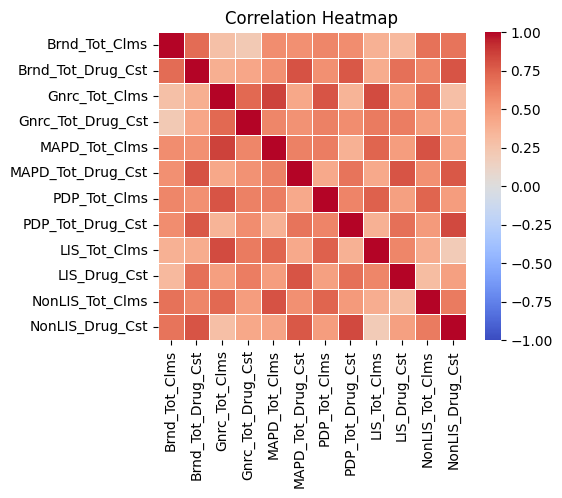

In [121]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    gbip_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [122]:
# Running the Principal Component Reduction.

gbip_pca = PCA(n_components = 6)
gbip_pca_c = gbip_pca.fit_transform(X_gbip)

In [123]:
# Looking at the variability explained by each component in gbip.

gbip_pca.explained_variance_ratio_
gbip_ex_vratio = np.cumsum(gbip_pca.explained_variance_ratio_)
gbip_ex_vratio

array([0.80202161, 0.89434435, 0.94856242, 0.99442929, 0.99864745,
       0.99998915])

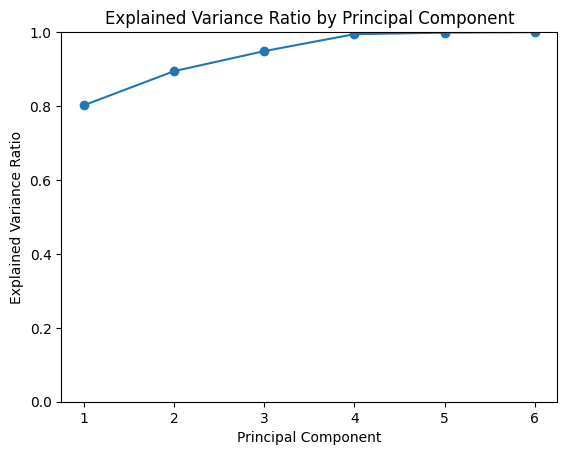

In [124]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(gbip_ex_vratio) + 1)
y = gbip_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [125]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

gbip_comps = gbip_pca.components_

gbip_comps_df = pd.DataFrame(
    gbip_comps,
    columns=X_gbip.columns,
    index=[f'PC{i+1}' for i in range(gbip_comps.shape[0])]
)

print(gbip_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Brnd_Tot_Clms  Brnd_Tot_Drug_Cst  Gnrc_Tot_Clms  Gnrc_Tot_Drug_Cst  \
PC1       0.001024           0.621280       0.001246           0.053856   
PC2      -0.001126           0.007344       0.002104           0.072159   
PC3       0.001274           0.769589      -0.000777          -0.119451   
PC4       0.000203          -0.137481      -0.000204          -0.042437   
PC5      -0.000478           0.052505       0.022301           0.985429   
PC6      -0.001581          -0.004449      -0.003458          -0.061388   

     MAPD_Tot_Clms  MAPD_Tot_Drug_Cst  PDP_Tot_Clms  PDP_Tot_Drug_Cst  \
PC1       0.001270           0.411228      0.001046          0.360817   
PC2       0.001020           0.269229      0.000028         -0.154210   
PC3       0.000444          -0.211341     -0.000202         -0.401720   
PC4       0.002052           0.679270     -0.002004         -0.654789   
PC5       0.012021          -0.069630      0.009429         -0.115999   
PC6      -0.004004          -0.49746

In [126]:
# From the ratio plot, the top variable explains 80% of the variance in the data.
# From the table above, Brnd_Tot_Drug_Cst (PC1 value = 0.62) would be that variable.
# However, given that this analysis chunk is made up of essentially 6 variables (brand name drugs, generic-brand drugs, MAPD plan, PDP plan, low-income status, and no low-income status) from 2 different groups (drug brand, insurance plan), I do not feel comfortable clustering only on one variable.
# Therefore, I will move forward with the Cst-related columns of each variable.

In [127]:
# Standardizing numeric data to zscore.

gbip_num = gbip[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip_numz = pd.DataFrame(stats.zscore(gbip_num, nan_policy = 'omit'), columns = gbip_num.columns)
gbip_numz.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874


In [128]:
# Comparing against mean values and standard deviations in each column in gbip_num.

print(gbip_num.describe())

       Brnd_Tot_Drug_Cst  Gnrc_Tot_Drug_Cst  MAPD_Tot_Drug_Cst  \
count       1.380665e+06       1.380665e+06       1.380665e+06   
mean        1.343237e+05       2.857522e+04       1.092079e+05   
std         5.309747e+05       7.993814e+04       3.699074e+05   
min         0.000000e+00       0.000000e+00       0.000000e+00   
25%         0.000000e+00       6.326200e+02       2.722100e+02   
50%         0.000000e+00       3.320050e+03       5.207970e+03   
75%         5.681983e+04       2.341040e+04       6.510144e+04   
max         1.601750e+08       1.832377e+07       7.876053e+07   

       PDP_Tot_Drug_Cst  LIS_Drug_Cst  NonLIS_Drug_Cst  Opioid_Tot_Benes_norm  \
count      1.380665e+06  1.380665e+06     1.380665e+06           1.380665e+06   
mean       8.798766e+04  9.437112e+04     1.032235e+05           2.420434e-01   
std        3.338271e+05  3.297399e+05     4.214994e+05           3.307473e-01   
min        0.000000e+00  0.000000e+00     0.000000e+00           0.000000e+00   


In [129]:
# The gbip-num data frame serves as the final data set because this subset does not include categorical data.

gbip_f = gbip_numz.copy()
gbip_f.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874


In [130]:
# Check for null values per column.

print(gbip_f.isnull().sum())

Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Drug_Cst               0
LIS_Drug_Cst                   0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [131]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

gbip_f_10 = gbip_f.sample(frac = 0.01, random_state = 0)
gbip_f_10.describe()

# Remove opioid data from prdemo_f.

gbip_fo_10 = gbip_f_10[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst']]
gbip_fo_10.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst
941935,1.042105,-0.056050,1.341840,0.063089,1.683260,-0.090202
123147,-0.252976,0.498417,0.203244,0.216468,-0.000516,0.349266
529198,-0.252878,-0.314235,-0.292355,-0.256250,-0.283819,-0.238435
28890,0.640433,0.510573,0.135782,0.887719,0.287148,0.596652
804529,-0.252976,-0.335080,-0.295230,-0.263573,-0.281720,-0.244079


In [132]:
# Convert the data frame to a matrix.

gbip_fmat = gbip_fo_10.to_numpy()

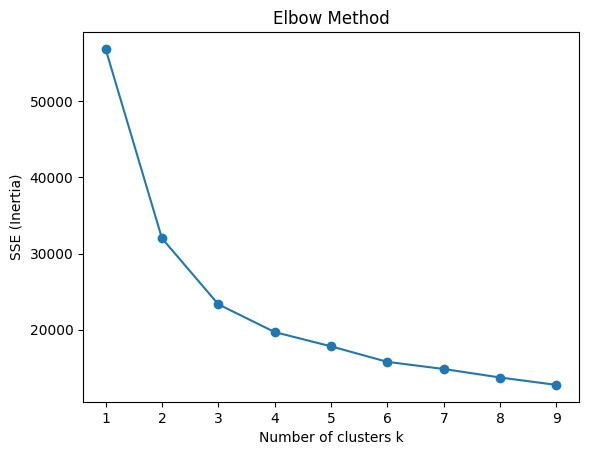

In [133]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_gbip = KMeans(n_clusters=k, random_state=42).fit(gbip_fmat)
    
    distortions.append(sum(np.min(cdist(gbip_fmat, kmeans_gbip.cluster_centers_, 'euclidean'), axis=1)**2) / gbip_fmat.shape[0])
    
    inertias.append(kmeans_gbip.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [134]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_gbip = KMeans(n_clusters=3, random_state=42).fit(gbip_fmat)

In [135]:
# Cluster centorid

kmeans_gbip.cluster_centers_

array([[-0.17656015, -0.20190165, -0.19988528, -0.18020751, -0.19537039,
        -0.16664829],
       [ 5.1338202 ,  3.74828278,  5.73496985,  4.55062124,  5.67845571,
         4.45249735],
       [ 1.15772784,  1.4078151 ,  1.25918577,  1.12828973,  1.18796866,
         1.08358569]])

In [136]:
# Check the iteration of the clusters created

kmeans_gbip.n_iter_

33

In [137]:
# Check the cost of the clusters created

kmeans_gbip.inertia_

23341.20361488638

In [138]:
# Add the clusters to the gbip_f_10 dataframe.

gbip_f_10['Cluster Labels'] = kmeans_gbip.labels_
gbip_f_10['Segment'] = gbip_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
gbip_f_10['Segment'] = gbip_f_10['Segment'].astype('category')
gbip_f_10['Segment'] = gbip_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

gbip_f_10.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,1.042105,-0.056050,1.341840,0.063089,1.683260,-0.090202,-0.441091,-0.333759,-0.240141,-0.119874,2,Cluster 3
123147,-0.252976,0.498417,0.203244,0.216468,-0.000516,0.349266,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1
529198,-0.252878,-0.314235,-0.292355,-0.256250,-0.283819,-0.238435,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1
28890,0.640433,0.510573,0.135782,0.887719,0.287148,0.596652,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1
804529,-0.252976,-0.335080,-0.295230,-0.263573,-0.281720,-0.244079,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
36793,-0.252976,-0.356349,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
1370028,0.019424,0.191634,-0.227900,0.226578,-0.059751,0.025241,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
1010928,-0.252976,-0.319876,-0.290507,-0.245637,-0.285242,-0.227294,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1
1253327,-0.252976,-0.348105,-0.295230,-0.263573,-0.282184,-0.240616,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
227991,-0.252976,-0.339843,-0.295230,-0.259162,-0.284032,-0.243098,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1


In [139]:
# Cluster interpretation

gbip_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
gbip_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Brnd_Tot_Drug_Cst': 'mean',
        'Gnrc_Tot_Drug_Cst': 'mean',
        'MAPD_Tot_Drug_Cst': 'mean',
        'PDP_Tot_Drug_Cst': 'mean',
        'LIS_Drug_Cst': 'mean',
        'NonLIS_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/570426374.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,12350,-0.176566,-0.201893,-0.199857,-0.180062,-0.195220,-0.166626,0.048843,0.002766,0.047592,-0.016995
1,Cluster 2,132,5.133820,3.748283,5.734970,4.550621,5.678456,4.452497,-0.515098,-0.247059,-0.465389,-0.010319
2,Cluster 3,1325,1.158793,1.408949,1.260023,1.127923,1.187613,1.084319,-0.511331,-0.096199,-0.478556,0.136090


In [140]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_gbip2 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [141]:
# Cluster centorid

kmeans_gbip2.cluster_centers_

array([[-0.12123463],
       [ 3.17414395]])

In [142]:
# Check the iteration of the clusters created

kmeans_gbip2.n_iter_

5

In [143]:
# Check the cost of the clusters created

kmeans_gbip2.inertia_

3739.0087743493586

In [144]:
# Add the clusters to the gbip_f_10 dataframe.

gbip_f_102 = gbip_f_10.copy()

gbip_f_102['Cluster Labels'] = kmeans_gbip2.labels_
gbip_f_102['Segment'] = gbip_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
gbip_f_102['Segment'] = gbip_f_102['Segment'].astype('category')
gbip_f_102['Segment'] = gbip_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

gbip_f_102.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Cluster Labels
941935,1.042105,-0.056050,1.341840,0.063089,1.683260,-0.090202,-0.441091,-0.333759,-0.240141,-0.119874,2,Cluster 1,0
123147,-0.252976,0.498417,0.203244,0.216468,-0.000516,0.349266,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1,0
529198,-0.252878,-0.314235,-0.292355,-0.256250,-0.283819,-0.238435,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1,0
28890,0.640433,0.510573,0.135782,0.887719,0.287148,0.596652,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1,0
804529,-0.252976,-0.335080,-0.295230,-0.263573,-0.281720,-0.244079,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1,0
36793,-0.252976,-0.356349,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0
1370028,0.019424,0.191634,-0.227900,0.226578,-0.059751,0.025241,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1,0
1010928,-0.252976,-0.319876,-0.290507,-0.245637,-0.285242,-0.227294,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1,0
1253327,-0.252976,-0.348105,-0.295230,-0.263573,-0.282184,-0.240616,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0
227991,-0.252976,-0.339843,-0.295230,-0.259162,-0.284032,-0.243098,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1,0


In [145]:
# Cluster interpretation

gbip_summary = gbip_f_102.groupby('Segment', observed=False).agg(
    Total=('Segment', 'count'),
    Brnd_Tot_Drug_Cst=('Brnd_Tot_Drug_Cst', 'mean'),
    Gnrc_Tot_Drug_Cst=('Gnrc_Tot_Drug_Cst', 'mean'),
    MAPD_Tot_Drug_Cst=('MAPD_Tot_Drug_Cst', 'mean'),
    PDP_Tot_Drug_Cst=('PDP_Tot_Drug_Cst', 'mean'),
    LIS_Drug_Cst=('LIS_Drug_Cst', 'mean'),
    NonLIS_Drug_Cst=('NonLIS_Drug_Cst', 'mean'),
    Opioid_Tot_Benes_norm=('Opioid_Tot_Benes_norm', 'mean'),
    Opioid_Cst_Per_Bene_norm=('Opioid_Cst_Per_Bene_norm', 'mean'),
    Opioid_LA_Tot_Benes_norm=('Opioid_LA_Tot_Benes_norm', 'mean'),
    Opioid_LA_Cst_Per_Bene_norm=('Opioid_LA_Cst_Per_Bene_norm', 'mean')
).reset_index()

gbip_summary

,Segment,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,13311,-0.098067,-0.095668,-0.116084,-0.108705,-0.109870,-0.103774,0.009307,-0.001225,0.009850,-0.002954
1,Cluster 2,496,2.697267,2.301790,3.031266,2.658042,2.771469,2.717668,-0.536644,-0.220975,-0.481596,0.016931


### Additional Medications Prescribed

In [146]:
# Creating subset of the data: additional medications prescribed + opioid data.

meds = opioid_norm[['Antbtc_Tot_Clms', 'Antbtc_Tot_Drug_Cst', 'Antbtc_Tot_Benes', 'Antbtc_Cst_Per_Bene', 'Antpsyct_GE65_Tot_Clms', 'Antpsyct_GE65_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Benes', 'Antpsyct_GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds.head()

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,42.0,731.76,39.0,18.763077,10.0,0.0,10.0,0.0,0.116071,0.020452,0.000000,0.000000
1,10.0,0.00,10.0,0.000000,0.0,0.0,0.0,0.0,0.748954,0.573070,0.050209,3.875878
2,60.0,266.45,49.0,5.437755,0.0,0.0,10.0,0.0,0.169492,0.000000,0.169492,0.000000
3,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.000000,0.000000,0.000000,0.000000
4,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.576923,0.047960,0.000000,0.000000


In [147]:
# Checking data types in meds.

print(meds.dtypes)

Antbtc_Tot_Clms                float64
Antbtc_Tot_Drug_Cst            float64
Antbtc_Tot_Benes               float64
Antbtc_Cst_Per_Bene            float64
Antpsyct_GE65_Tot_Clms         float64
Antpsyct_GE65_Tot_Drug_Cst     float64
Antpsyct_GE65_Tot_Benes        float64
Antpsyct_GE65_Cst_Per_Bene     float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [148]:
# Check for null values per column (ML).

print(meds.isnull().sum())

Antbtc_Tot_Clms                0
Antbtc_Tot_Drug_Cst            0
Antbtc_Tot_Benes               0
Antbtc_Cst_Per_Bene            0
Antpsyct_GE65_Tot_Clms         0
Antpsyct_GE65_Tot_Drug_Cst     0
Antpsyct_GE65_Tot_Benes        0
Antpsyct_GE65_Cst_Per_Bene     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [149]:
# Preparing for a Principal Component Reduction.

X_meds = meds.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
meds_corr = X_meds.corr()

meds_corr

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene
Antbtc_Tot_Clms,1.000000,0.267580,0.932777,0.055278,0.227800,0.074556,0.134117,0.036387
Antbtc_Tot_Drug_Cst,0.267580,1.000000,0.146993,0.631144,0.094352,0.039422,0.050234,0.015170
Antbtc_Tot_Benes,0.932777,0.146993,1.000000,0.004764,0.132801,0.032296,0.049299,0.010639
Antbtc_Cst_Per_Bene,0.055278,0.631144,0.004764,1.000000,0.003703,0.000034,-0.031479,-0.002818
Antpsyct_GE65_Tot_Clms,0.227800,0.094352,0.132801,0.003703,1.000000,0.568195,0.785182,0.288654
Antpsyct_GE65_Tot_Drug_Cst,0.074556,0.039422,0.032296,0.000034,0.568195,1.000000,0.454553,0.683327
Antpsyct_GE65_Tot_Benes,0.134117,0.050234,0.049299,-0.031479,0.785182,0.454553,1.000000,0.197069
Antpsyct_GE65_Cst_Per_Bene,0.036387,0.015170,0.010639,-0.002818,0.288654,0.683327,0.197069,1.000000


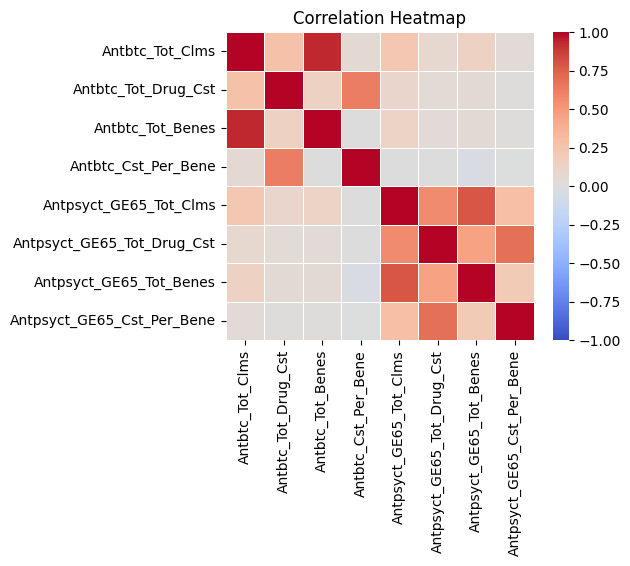

In [150]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    meds_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [151]:
# Running the Principal Component Reduction.

meds_pca = PCA(n_components = 6)
meds_pca_c = meds_pca.fit_transform(X_meds)

In [152]:
# Looking at the variability explained by each component in meds.

meds_pca.explained_variance_ratio_
meds_ex_vratio = np.cumsum(meds_pca.explained_variance_ratio_)
meds_ex_vratio

array([0.53326324, 0.99939351, 0.99975464, 0.99997646, 0.99999493,
       0.99999951])

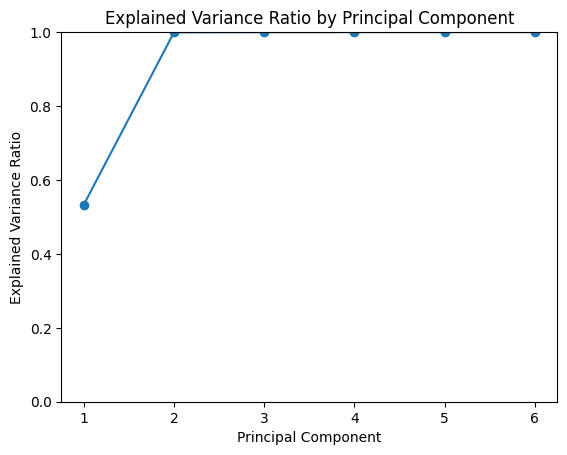

In [153]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(meds_ex_vratio) + 1)
y = meds_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [154]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

meds_comps = meds_pca.components_

meds_comps_df = pd.DataFrame(
    meds_comps,
    columns=X_meds.columns,
    index=[f'PC{i+1}' for i in range(meds_comps.shape[0])]
)

print(meds_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Antbtc_Tot_Clms  Antbtc_Tot_Drug_Cst  Antbtc_Tot_Benes  \
PC1         0.000786             0.307739          0.000232   
PC2         0.001317             0.951305          0.000441   
PC3        -0.003888             0.000158         -0.001954   
PC4        -0.040815            -0.017575         -0.019386   
PC5         0.851617            -0.002367          0.507316   
PC6        -0.065512            -0.000195         -0.131106   

     Antbtc_Cst_Per_Bene  Antpsyct_GE65_Tot_Clms  Antpsyct_GE65_Tot_Drug_Cst  \
PC1             0.004810                0.002082                    0.951173   
PC2             0.017007               -0.000377                   -0.307674   
PC3             0.017091               -0.019605                   -0.024477   
PC4             0.998622               -0.009781                    0.001123   
PC5             0.045938                0.123063                   -0.000711   
PC6             0.004913                0.983154                   -0.002516  

In [155]:
# From the ratio plot, the top 2 variables explain >99% of the variance in the data.
# From the table above, Antpsyct_GE65_Tot_Drug_Cst (PC1 value = 0.98, 56% of variance) and Antbtc_Tot_Drug_Cst (PC2 value = 0.98, >99% of variance) would be those variables.
# With such high variance (>99%) explained by two variables, overfitting is a concern, but including both variables seems necessary.
# Each variable represents a different medication: antibiotics and antipsychotics.

In [156]:
# Standardizing numeric data to zscore.

meds_num = meds[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds_numz = pd.DataFrame(stats.zscore(meds_num, nan_policy = 'omit'), columns = meds_num.columns)
meds_numz.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.074067,-0.09754,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.118762,-0.09754,1.532623,2.616815,-0.384133,10.377701
2,-0.102488,-0.09754,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.118762,-0.09754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.118762,-0.09754,1.012495,-0.086828,-0.541490,-0.119874


In [157]:
# Comparing against mean values and standard deviations in each column in meds_num.

print(meds_num.describe())

       Antbtc_Tot_Drug_Cst  Antpsyct_GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  \
count         1.380665e+06                1.380665e+06           1.380665e+06   
mean          1.944425e+03                1.686178e+03           2.420434e-01   
std           1.637246e+04                1.728702e+04           3.307473e-01   
min           0.000000e+00                0.000000e+00           0.000000e+00   
25%           0.000000e+00                0.000000e+00           0.000000e+00   
50%           1.086000e+02                0.000000e+00           8.695652e-02   
75%           6.854500e+02                0.000000e+00           3.333333e-01   
max           8.775029e+06                6.524661e+06           1.000000e+00   

       Opioid_Cst_Per_Bene_norm  Opioid_LA_Tot_Benes_norm  \
count              1.380665e+06              1.380665e+06   
mean               6.482383e-02              1.727777e-01   
std                1.942233e-01              3.190786e-01   
min                0.00000

In [158]:
# The meds-num data frame serves as the final data set because this subset does not include categorical data.

meds_f = meds_numz.copy()
meds_f.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.074067,-0.09754,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.118762,-0.09754,1.532623,2.616815,-0.384133,10.377701
2,-0.102488,-0.09754,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.118762,-0.09754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.118762,-0.09754,1.012495,-0.086828,-0.541490,-0.119874


In [159]:
# Check for null values per column.

print(meds_f.isnull().sum())

Antbtc_Tot_Drug_Cst            0
Antpsyct_GE65_Tot_Drug_Cst     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [160]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

meds_f_10 = meds_f.sample(frac = 0.01, random_state = 0)
meds_f_10.describe()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000
mean,-0.002022,-0.013726,-0.010306,-0.009119,-0.007804,-0.002240
std,0.790696,0.686025,0.997016,0.966796,0.995735,1.117683
min,-0.118762,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874
25%,-0.118762,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874
50%,-0.112646,-0.097540,-0.479284,-0.333759,-0.541490,-0.119874
75%,-0.077325,-0.097540,0.233319,-0.209533,-0.080604,-0.119874
max,28.765208,30.180065,2.291650,14.339094,2.592535,50.093505


In [161]:
# Remove opioid data from meds_f.

meds_fo_10 = meds_f_10[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst']]
meds_fo_10.head()


,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst
941935,-0.102960,-0.09754
123147,0.112668,-0.09754
529198,-0.094382,-0.09754
28890,-0.114060,-0.09754
804529,-0.083702,-0.09754


In [162]:
# Convert the data frame to a matrix.

meds_fmat = meds_fo_10.to_numpy()

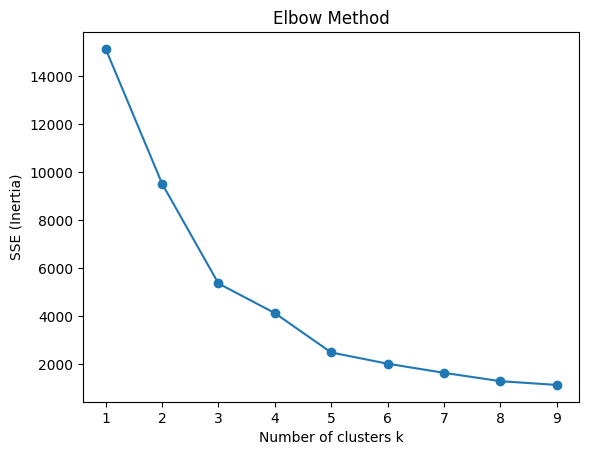

In [163]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_meds = KMeans(n_clusters=k, random_state=42).fit(meds_fmat)
    
    distortions.append(sum(np.min(cdist(meds_fmat, kmeans_meds.cluster_centers_, 'euclidean'), axis=1)**2) / meds_fmat.shape[0])
    
    inertias.append(kmeans_meds.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [164]:
#Run k-means using k clusters as determined from the elbow plot above.

kmeans_meds = KMeans(n_clusters=2, random_state=42).fit(meds_fmat)

In [165]:
# Cluster centorid

kmeans_meds.cluster_centers_

array([[-0.03368872, -0.01408114],
       [12.82566506,  0.1302296 ]])

In [166]:
# Check the iteration of the clusters created

kmeans_meds.n_iter_

3

In [167]:
# Check the cost of the clusters created

kmeans_meds.inertia_

9519.836420947526

In [168]:
# Add the clusters to the meds_f_10 dataframe.

meds_f_10['Cluster Labels'] = kmeans_meds.labels_
meds_f_10['Segment'] = meds_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})
# Order the cluster

meds_f_10['Segment'] = meds_f_10['Segment'].astype('category')
meds_f_10['Segment'] = meds_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])
meds_f_10.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,-0.102960,-0.097540,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1
123147,0.112668,-0.097540,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1
529198,-0.094382,-0.097540,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1
28890,-0.114060,-0.097540,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1
804529,-0.083702,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
36793,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
1370028,-0.118762,0.229173,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
1010928,-0.104414,-0.097540,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1
1253327,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
227991,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1


In [169]:
# Add the clusters to the meds_f_10 dataframe.

meds_f_10['Cluster Labels'] = kmeans_meds.labels_
meds_f_10['Segment'] = meds_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
meds_f_10['Segment'] = meds_f_10['Segment'].astype('category')
meds_f_10['Segment'] = meds_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

meds_f_10.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,-0.102960,-0.097540,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1
123147,0.112668,-0.097540,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1
529198,-0.094382,-0.097540,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1
28890,-0.114060,-0.097540,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1
804529,-0.083702,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
36793,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
1370028,-0.118762,0.229173,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
1010928,-0.104414,-0.097540,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1
1253327,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
227991,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1


In [170]:
# Cluster interpretation

meds_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
meds_summary = meds_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Antbtc_Tot_Drug_Cst': 'mean',
        'Antpsyct_GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

print(meds_summary)

     Segment  Total  Antbtc_Tot_Drug_Cst  Antpsyct_GE65_Tot_Drug_Cst  \
0  Cluster 1  13773            -0.033689                   -0.014081   
1  Cluster 2     34            12.825665                    0.130230   

   Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  Opioid_LA_Tot_Benes_norm  \
0              -0.008712                  -0.00836                 -0.006629   
1              -0.655924                  -0.31688                 -0.483859   

   Opioid_LA_Cst_Per_Bene_norm  
0                    -0.001951  
1                    -0.119197  


/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/2638893594.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


### Beneficiary Demographics

In [171]:
# Creating subset of the data: patient demographics + opioid data.

bene = opioid_norm[['Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene.head()

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,76.196429,16.0,66.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,0.116071,0.020452,0.000000,0.000000
1,66.581590,188.0,270.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,0.748954,0.573070,0.050209,3.875878
2,72.355932,10.0,0.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.169492,0.000000,0.169492,0.000000
3,69.984375,10.0,0.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.000000,0.000000,0.000000,0.000000
4,63.884615,10.0,0.0,10.0,15.0,11.0,19.0,10.0,0.0,10.0,0.0,10.0,0.576923,0.047960,0.000000,0.000000


In [172]:
# Checking data types in bene.

print(bene.dtypes)

Bene_Avg_Age                   float64
Bene_Age_LT_65_Cnt             float64
Bene_Age_65_84_Cnt             float64
Bene_Age_GT_84_Cnt             float64
Bene_Feml_Cnt                  float64
Bene_Male_Cnt                  float64
Bene_Race_Wht_Cnt              float64
Bene_Race_Black_Cnt            float64
Bene_Race_Api_Cnt              float64
Bene_Race_Hspnc_Cnt            float64
Bene_Race_Natind_Cnt           float64
Bene_Race_Othr_Cnt             float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [173]:
# Check for null values per column (ML).

print(bene.isnull().sum())

Bene_Avg_Age                   0
Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [174]:
# Preparing for a Principal Component Reduction.

X_bene = bene.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
bene_corr = X_bene.corr()

bene_corr

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
Bene_Avg_Age,1.000000,-0.086063,0.038174,0.080513,0.045927,0.048410,0.051971,0.001427,0.026664,0.025470,-0.040745,0.022562
Bene_Age_LT_65_Cnt,-0.086063,1.000000,0.818816,0.773674,0.835207,0.823159,0.810082,0.768164,0.463198,0.598809,0.165048,0.726082
Bene_Age_65_84_Cnt,0.038174,0.818816,1.000000,0.968220,0.995754,0.994610,0.980490,0.766810,0.650958,0.699015,0.138088,0.951100
Bene_Age_GT_84_Cnt,0.080513,0.773674,0.968220,1.000000,0.966294,0.969506,0.952391,0.714059,0.655723,0.687196,0.141846,0.929848
Bene_Feml_Cnt,0.045927,0.835207,0.995754,0.966294,1.000000,0.990483,0.981191,0.776616,0.645074,0.696564,0.138396,0.945802
Bene_Male_Cnt,0.048410,0.823159,0.994610,0.969506,0.990483,1.000000,0.978822,0.759297,0.657142,0.702609,0.138991,0.950831
Bene_Race_Wht_Cnt,0.051971,0.810082,0.980490,0.952391,0.981191,0.978822,1.000000,0.742837,0.542838,0.575086,0.129473,0.926739
Bene_Race_Black_Cnt,0.001427,0.768164,0.766810,0.714059,0.776616,0.759297,0.742837,1.000000,0.371628,0.457996,0.102238,0.661662
Bene_Race_Api_Cnt,0.026664,0.463198,0.650958,0.655723,0.645074,0.657142,0.542838,0.371628,1.000000,0.695412,0.108494,0.729022
Bene_Race_Hspnc_Cnt,0.025470,0.598809,0.699015,0.687196,0.696564,0.702609,0.575086,0.457996,0.695412,1.000000,0.104743,0.663369


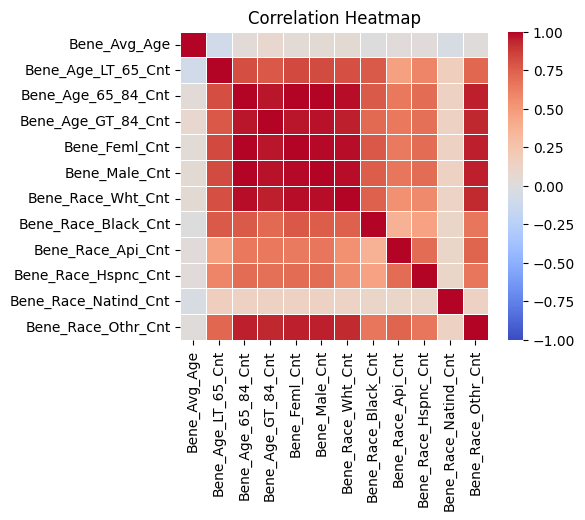

In [175]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    bene_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [176]:
# Running the Principal Component Reduction.

bene_pca = PCA(n_components = 6)
bene_pca_c = bene_pca.fit_transform(X_bene)

In [177]:
# Looking at the variability explained by each component in bene.

bene_pca.explained_variance_ratio_
bene_ex_vratio = np.cumsum(bene_pca.explained_variance_ratio_)
bene_ex_vratio

array([0.97952445, 0.99308141, 0.99543126, 0.99719504, 0.99834467,
       0.99929022])

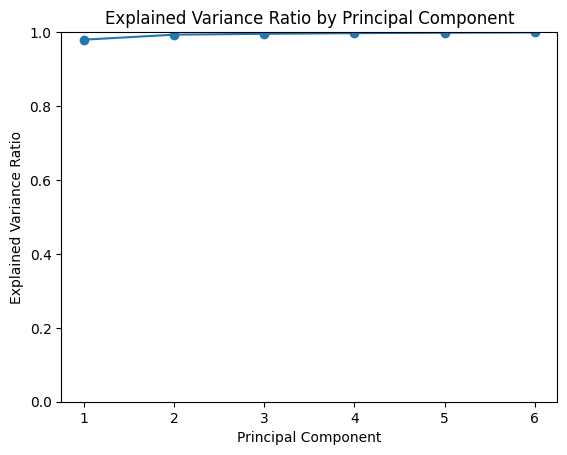

In [178]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(bene_ex_vratio) + 1)
y = bene_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [179]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

bene_comps = bene_pca.components_

bene_comps_df = pd.DataFrame(
    bene_comps,
    columns=X_bene.columns,
    index=[f'PC{i+1}' for i in range(bene_comps.shape[0])]
)

print(bene_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Bene_Avg_Age  Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
PC1      0.000233            0.035229            0.639379            0.061784   
PC2      0.001505           -0.015569           -0.287274           -0.030227   
PC3     -0.009389            0.222755            0.068795           -0.075886   
PC4     -0.003143           -0.183507            0.281612            0.029188   
PC5      0.005549            0.079258           -0.287542            0.003470   
PC6      0.008613            0.320830           -0.536942            0.067784   

     Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
PC1       0.419028       0.317123           0.547941             0.050061   
PC2      -0.152365      -0.139215           0.638143            -0.007460   
PC3       0.262682      -0.153325          -0.228381             0.831014   
PC4      -0.124520       0.060866          -0.233214             0.065540   
PC5       0.717379      -0.482388           0.0

In [180]:
# From the ratio plot, the top variable explains 98% of the variance in the data.
# From the table above, Bene_Age_65_84_Cnt (PC1 value = 0.64) would be that variable.
# However, given that this analysis chunk is made up of essentially mostly non-overlapping variables (except for Bene_Avg_Age).
# Therefore, all variables, except for Bene_Avg_Age, will be used in the cluster.

In [181]:
# Standardizing numeric data to zscore.

bene_num = bene[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene_numz = pd.DataFrame(stats.zscore(bene_num, nan_policy = 'omit'), columns = bene_num.columns)
bene_numz.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874


In [182]:
# Comparing against mean values and standard deviations in each column in bene_num.

print(bene_num.describe())

       Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
count        1.380665e+06        1.380665e+06        1.380665e+06   
mean         2.403406e+01        9.965139e+01        1.989761e+01   
std          5.171221e+01        7.755029e+02        7.721835e+01   
min          0.000000e+00        0.000000e+00        0.000000e+00   
25%          1.000000e+01        0.000000e+00        1.000000e+01   
50%          1.000000e+01        1.100000e+01        1.000000e+01   
75%          2.600000e+01        1.270000e+02        1.500000e+01   
max          2.158900e+04        4.286940e+05        4.399300e+04   

       Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
count   1.380665e+06   1.380665e+06       1.380665e+06         1.380665e+06   
mean    9.384940e+01   6.735218e+01       1.172071e+02         2.127122e+01   
std     5.088425e+02   3.858250e+02       6.696899e+02         7.920985e+01   
min     0.000000e+00   0.000000e+00       0.000000e+00        

In [183]:
# The bene-num data frame serves as the final data set because this subset does not include categorical data.

bene_f = bene_numz.copy()
bene_f.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874


In [184]:
# Check for null values per column.

print(bene_f.isnull().sum())

Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [185]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

bene_f_10 = bene_f.sample(frac = 0.01, random_state = 0)
bene_f_10.describe()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000,13807.000000
mean,-0.004937,-0.003670,-0.005155,-0.002888,-0.004064,-0.004083,-0.001247,0.002740,-0.001695,-0.006022,-0.001490,-0.010306,-0.009119,-0.007804,-0.002240
std,0.703834,0.234187,0.343469,0.260575,0.260807,0.261627,0.568461,0.559517,0.471108,1.052152,0.209017,0.997016,0.966796,0.995735,1.117683
min,-0.464766,-0.128499,-0.257680,-0.184437,-0.174567,-0.175017,-0.268543,-0.135930,-0.159182,-0.512537,-0.264218,-0.731808,-0.333759,-0.541490,-0.119874
25%,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.154112,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874
50%,-0.271388,-0.128499,-0.128177,-0.099932,-0.099403,-0.104835,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.479284,-0.333759,-0.541490,-0.119874
75%,0.038017,0.037845,-0.076376,0.053358,0.030189,0.038515,-0.079172,0.003357,-0.081470,1.123662,0.011267,0.233319,-0.209533,-0.080604,-0.119874
max,44.321581,9.007511,6.424672,11.571660,10.024362,10.025230,26.634687,43.739462,12.383465,48.409802,8.854363,2.291650,14.339094,2.592535,50.093505


In [186]:
# Remove opioid data from bene_f.

bene_fo_10 = bene_f_10[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt']]
bene_fo_10.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
941935,0.463449,-0.074341,-0.128177,-0.103862,-0.011280,-0.152619,0.488939,0.003357,0.004012,-0.512537,0.011267
123147,1.043583,0.209346,0.130829,0.432650,-0.029423,0.292364,0.097573,0.003357,-0.081470,1.123662,0.121462
529198,-0.271388,0.153898,-0.128177,0.098558,0.087210,0.050460,0.539438,0.003357,0.035097,-0.512537,0.011267
28890,0.057355,0.401480,1.594212,0.352075,0.623723,0.496936,-0.053923,0.003357,0.221605,1.123662,1.333599
804529,-0.271388,0.006897,-0.128177,-0.029183,-0.037199,-0.160085,-0.117046,0.003357,0.711188,-0.512537,-0.264218


In [187]:
# Convert the data frame to a matrix.

bene_fmat = bene_fo_10.to_numpy()

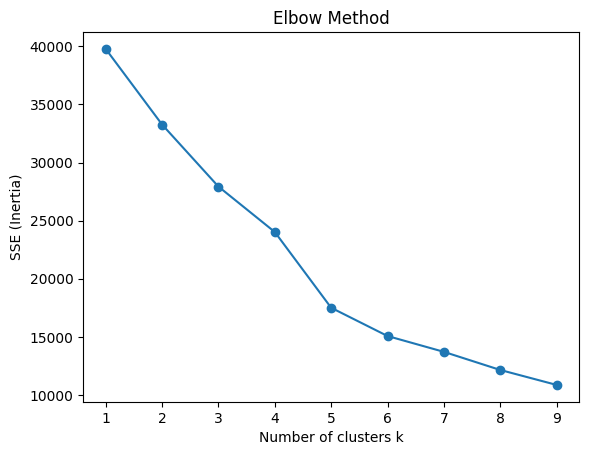

In [188]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []
K = range(1, 10)

for k in K:
    kmeans_bene = KMeans(n_clusters=k, random_state=42).fit(bene_fmat)
    
    distortions.append(sum(np.min(cdist(bene_fmat, kmeans_bene.cluster_centers_, 'euclidean'), axis=1)**2) / bene_fmat.shape[0])
    
    inertias.append(kmeans_bene.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [189]:
#Run k-means using 1 cluster as determined from the elbow plot above.

kmeans_bene = KMeans(n_clusters=1, random_state=42).fit(bene_fmat)

In [190]:
# Cluster centorid

kmeans_bene.cluster_centers_

array([[-0.00493742, -0.00367044, -0.00515523, -0.00288755, -0.00406369,
        -0.00408287, -0.00124698,  0.00273977, -0.00169496, -0.0060225 ,
        -0.00149031]])

In [191]:
# Check the iteration of the clusters created

kmeans_bene.n_iter_

2

In [192]:
# Check the cost of the clusters created

kmeans_bene.inertia_

39780.98697412104

In [193]:
# Add the clusters to the prdemo_f_10 dataframe.

bene_f_10['Cluster Labels'] = kmeans_bene.labels_
bene_f_10['Segment'] = bene_f_10['Cluster Labels'].map({0: 'Cluster 1'})

# Order the cluster
bene_f_10['Segment'] = bene_f_10['Segment'].astype('category')
bene_f_10['Segment'] = bene_f_10['Segment'].cat.reorder_categories(['Cluster 1'])

bene_f_10.head(10)

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
941935,0.463449,-0.074341,-0.128177,-0.103862,-0.011280,-0.152619,0.488939,0.003357,0.004012,-0.512537,0.011267,-0.441091,-0.333759,-0.240141,-0.119874,0,Cluster 1
123147,1.043583,0.209346,0.130829,0.432650,-0.029423,0.292364,0.097573,0.003357,-0.081470,1.123662,0.121462,-0.650093,-0.333759,-0.456786,-0.119874,0,Cluster 1
529198,-0.271388,0.153898,-0.128177,0.098558,0.087210,0.050460,0.539438,0.003357,0.035097,-0.512537,0.011267,0.625663,3.217818,-0.413570,-0.119874,0,Cluster 1
28890,0.057355,0.401480,1.594212,0.352075,0.623723,0.496936,-0.053923,0.003357,0.221605,1.123662,1.333599,-0.679769,-0.333759,-0.487548,-0.119874,0,Cluster 1
804529,-0.271388,0.006897,-0.128177,-0.029183,-0.037199,-0.160085,-0.117046,0.003357,0.711188,-0.512537,-0.264218,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
36793,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
1370028,-0.155361,0.084266,-0.011624,-0.003635,0.105353,0.022089,-0.142296,0.184430,0.050639,1.123662,0.176559,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
1010928,-0.271388,-0.128499,-0.128177,0.021914,-0.034607,0.044488,-0.142296,0.003357,-0.159182,-0.512537,0.011267,1.226784,0.300534,-0.541490,-0.119874,0,Cluster 1
1253327,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
227991,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1


In [194]:
# Cluster interpretation

bene_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
bene_summary = bene_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Bene_Age_LT_65_Cnt': 'mean',
        'Bene_Age_65_84_Cnt': 'mean',
        'Bene_Age_GT_84_Cnt': 'mean',
        'Bene_Feml_Cnt': 'mean',
        'Bene_Male_Cnt': 'mean',
        'Bene_Race_Wht_Cnt': 'mean',
        'Bene_Race_Black_Cnt': 'mean',
        'Bene_Race_Api_Cnt': 'mean',
        'Bene_Race_Hspnc_Cnt': 'mean',
        'Bene_Race_Natind_Cnt': 'mean',
        'Bene_Race_Othr_Cnt': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

print(bene_summary)

     Segment  Total  Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  \
0  Cluster 1  13807           -0.004937            -0.00367   

   Bene_Age_GT_84_Cnt  Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  \
0           -0.005155      -0.002888      -0.004064          -0.004083   

   Bene_Race_Black_Cnt  Bene_Race_Api_Cnt  Bene_Race_Hspnc_Cnt  \
0            -0.001247            0.00274            -0.001695   

   Bene_Race_Natind_Cnt  Bene_Race_Othr_Cnt  Opioid_Tot_Benes_norm  \
0             -0.006022            -0.00149              -0.010306   

   Opioid_Cst_Per_Bene_norm  Opioid_LA_Tot_Benes_norm  \
0                 -0.009119                 -0.007804   

   Opioid_LA_Cst_Per_Bene_norm  
0                     -0.00224  


/var/folders/rv/44xpd82d2f90_qn3ydr0rvb40000gn/T/ipykernel_13405/3374249142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [195]:
# These large disparaties in the cluster sizes may be due to an imbalance in the classes.
# Therefore, future improvements would be a deeper dive into the data distributions to make sure that each class is evenly represented.

# Results and Analysis
### Julia Gonzalez

In [ ]:
# Variable name mapping - worked on a seperate notebook with a different variable name.
prdemo_f_10 = prdemo_f2
ge65_f_10 = ge65_f2
gbip_f_10 = gbip_f2
meds_f_10 = meds_f2
bene_f_10 = bene_f2

In [196]:

summary_data = {
    'Chunk': [
        'Prescriber Demographics', 'Prescriber Demographics',
        'Elderly Patients 65+', 'Elderly Patients 65+',
        'Generic/Brand & Insurance', 'Generic/Brand & Insurance',
        'Additional Medications', 'Additional Medications',
        'Beneficiary Demographics'
    ],
    'Cluster': [
        'Cluster 1', 'Cluster 2',
        'Cluster 1', 'Cluster 2',
        'Cluster 1', 'Cluster 2',
        'Cluster 1', 'Cluster 2',
        'Cluster 1'
    ],
    'N (providers)': [
        prdemo_summary.loc[0, 'Total'], prdemo_summary.loc[1, 'Total'],
        ge65_summary.loc[0, 'Total'], ge65_summary.loc[1, 'Total'],
        gbip_summary.loc[0, 'Total'], gbip_summary.loc[1, 'Total'],
        meds_summary.loc[0, 'Total'], meds_summary.loc[1, 'Total'],
        bene_summary.loc[0, 'Total']
    ],
    'Key Metric (z-score)': [
        round(prdemo_summary.loc[0, 'Tot_Clms'], 3), round(prdemo_summary.loc[1, 'Tot_Clms'], 3),
        round(ge65_summary.loc[0, 'GE65_Tot_Drug_Cst'], 3), round(ge65_summary.loc[1, 'GE65_Tot_Drug_Cst'], 3),
        round(gbip_summary.loc[0, 'Brnd_Tot_Drug_Cst'], 3), round(gbip_summary.loc[1, 'Brnd_Tot_Drug_Cst'], 3),
        round(meds_summary.loc[0, 'Antbtc_Tot_Drug_Cst'], 3), round(meds_summary.loc[1, 'Antbtc_Tot_Drug_Cst'], 3),
        round(bene_summary.loc[0, 'Bene_Age_LT_65_Cnt'], 3)
    ],
    'Key Metric Label': [
        'Total Claims', 'Total Claims',
        'Elderly Drug Cost', 'Elderly Drug Cost',
        'Brand Drug Cost', 'Brand Drug Cost',
        'Antibiotic Cost', 'Antibiotic Cost',
        'Age < 65 Count'
    ],
    'Opioid Beneficiary Rate': [
        round(prdemo_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3), round(prdemo_summary.loc[1, 'Opioid_Tot_Benes_norm'], 3),
        round(ge65_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3), round(ge65_summary.loc[1, 'Opioid_Tot_Benes_norm'], 3),
        round(gbip_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3), round(gbip_summary.loc[1, 'Opioid_Tot_Benes_norm'], 3),
        round(meds_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3), round(meds_summary.loc[1, 'Opioid_Tot_Benes_norm'], 3),
        round(bene_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3)
    ],
    'Opioid Cost Per Beneficiary': [
        round(prdemo_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3), round(prdemo_summary.loc[1, 'Opioid_Cst_Per_Bene_norm'], 3),
        round(ge65_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3), round(ge65_summary.loc[1, 'Opioid_Cst_Per_Bene_norm'], 3),
        round(gbip_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3), round(gbip_summary.loc[1, 'Opioid_Cst_Per_Bene_norm'], 3),
        round(meds_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3), round(meds_summary.loc[1, 'Opioid_Cst_Per_Bene_norm'], 3),
        round(bene_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3)
    ]
}

comprehensive_summary = pd.DataFrame(summary_data)
comprehensive_summary

,Chunk,Cluster,N (providers),Key Metric (z-score),Key Metric Label,Opioid Beneficiary Rate,Opioid Cost Per Beneficiary
0,Prescriber Demographics,Cluster 1,1111,2.266,Total Claims,-0.501,-0.009
1,Prescriber Demographics,Cluster 2,12696,-0.202,Total Claims,0.033,-0.009
2,Elderly Patients 65+,Cluster 1,13311,-0.121,Elderly Drug Cost,0.009,-0.001
3,Elderly Patients 65+,Cluster 2,496,3.181,Elderly Drug Cost,-0.537,-0.221
4,Generic/Brand & Insurance,Cluster 1,13311,-0.098,Brand Drug Cost,0.009,-0.001
5,Generic/Brand & Insurance,Cluster 2,496,2.697,Brand Drug Cost,-0.537,-0.221
6,Additional Medications,Cluster 1,13773,-0.034,Antibiotic Cost,-0.009,-0.008
7,Additional Medications,Cluster 2,34,12.826,Antibiotic Cost,-0.656,-0.317
8,Beneficiary Demographics,Cluster 1,13807,-0.005,Age < 65 Count,-0.010,-0.009


## Model Performance Evaluation
### Silhouette Scores

Silhouette scores measure how well each provider fits within its assigned cluster compared to other clusters. Scores range from -1 to 1, where a score closer to 1 indicates well-defined, clearly separated clusters. Note that silhouette scores are only calculated for the K-Means chunks — the K-Prototypes model used for Prescriber Demographics handles mixed data types and is not compatible with standard Euclidean distance-based evaluation metrics.

In [197]:
from sklearn.metrics import silhouette_score

# Silhouette scores for each chunk (K-Means only - not applicable for K-Prototypes)
ge65_sil = silhouette_score(ge65_fmat, kmeans_ge652.labels_)
gbip_sil = silhouette_score(gbip_fmat, kmeans_gbip.labels_)
meds_sil = silhouette_score(meds_fmat, kmeans_meds.labels_)

print(f'Elderly Patients 65+ silhouette score: {round(ge65_sil, 3)}')
print(f'Generic/Brand & Insurance silhouette score: {round(gbip_sil, 3)}')
print(f'Additional Medications silhouette score: {round(meds_sil, 3)}')

Elderly Patients 65+ silhouette score: 0.892
Generic/Brand & Insurance silhouette score: 0.794
Additional Medications silhouette score: 0.975


## Provider Analysis

In [198]:
# Filter for pain management providers
pain_mgmt = df_op[df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)]

print(f'Total pain management providers: {len(pain_mgmt)}')
print(f'\nTop prescriber types found:')
print(pain_mgmt['Prscrbr_Type'].value_counts().head(10))

Total pain management providers: 4431

Top prescriber types found:
Prscrbr_Type
Pain Management                   2816
Interventional Pain Management    1615
Name: count, dtype: int64


In [199]:
# Compare pain management opioid metrics vs all other providers
pain_mgmt_avg = pain_mgmt[['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']].mean()
all_others_avg = df_op[~df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)][['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']].mean()

comparison = pd.DataFrame({
    'Pain Management': pain_mgmt_avg,
    'All Other Providers': all_others_avg
})

print(comparison)

                     Pain Management  All Other Providers
Opioid_Tot_Clms          1113.267885            41.244009
Opioid_Prscrbr_Rate        40.690496             4.632804
Opioid_Tot_Suply        30654.956218           783.333303
Opioid_Cst_Per_Bene       304.755668            22.890599


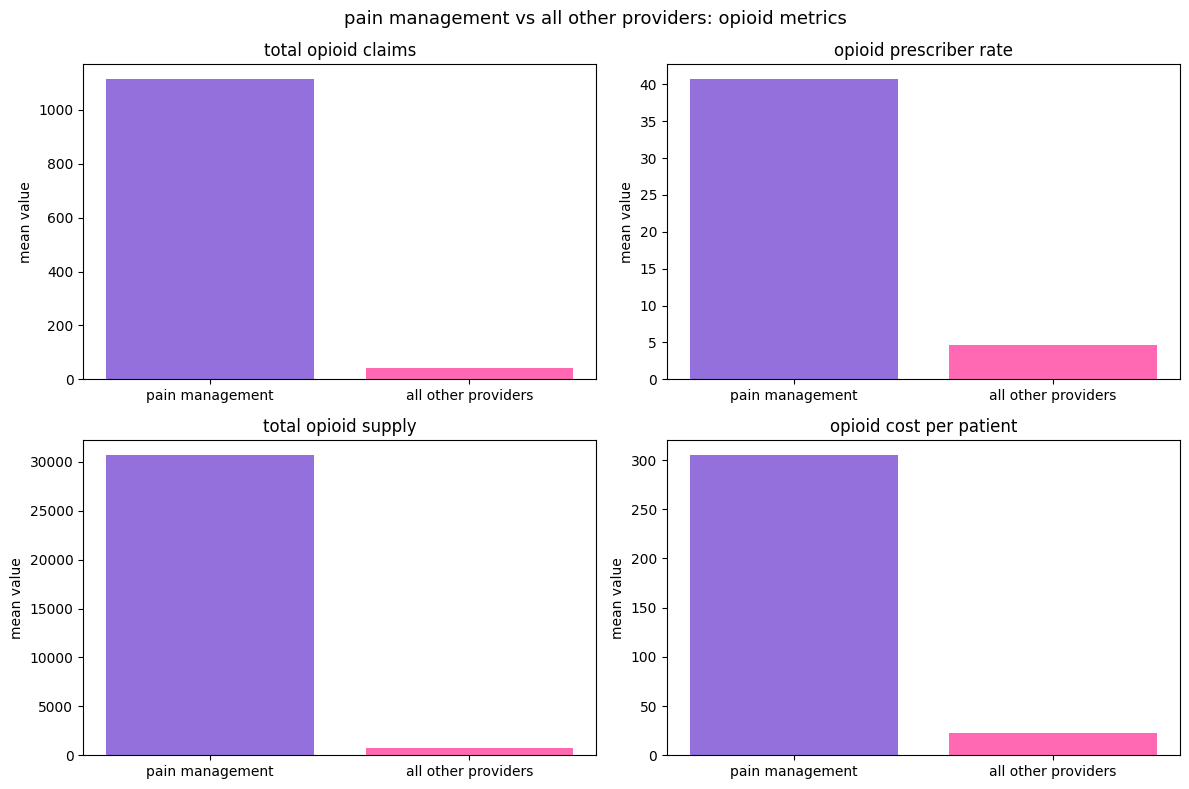

In [203]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(metrics, labels)):
    axes[i].bar(['pain management', 'all other providers'], 
                [pain_mgmt_avg[metric], all_others_avg[metric]], 
                color=['mediumpurple', 'hotpink'])
    axes[i].set_title(label)
    axes[i].set_ylabel('mean value')

plt.suptitle('pain management vs all other providers: opioid metrics', fontsize=13)
plt.tight_layout()
plt.show()

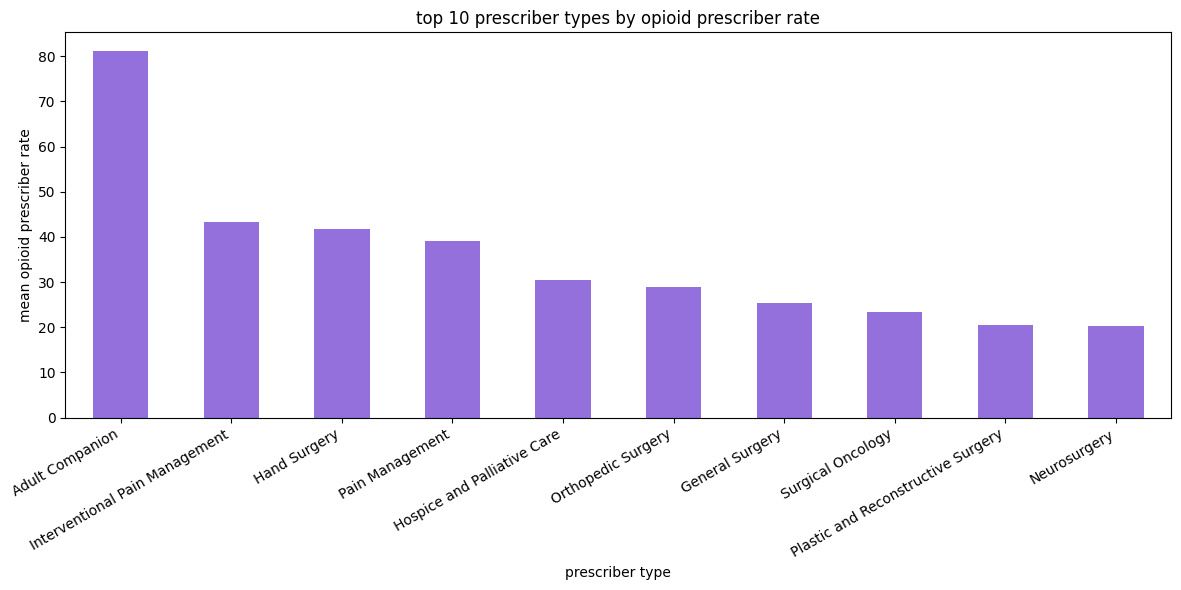

In [204]:
# top 10 prescriber types by opioid prescriber rate
top10 = df_op.groupby('Prscrbr_Type')['Opioid_Prscrbr_Rate'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top10.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('top 10 prescriber types by opioid prescriber rate')
ax.set_xlabel('prescriber type')
ax.set_ylabel('mean opioid prescriber rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

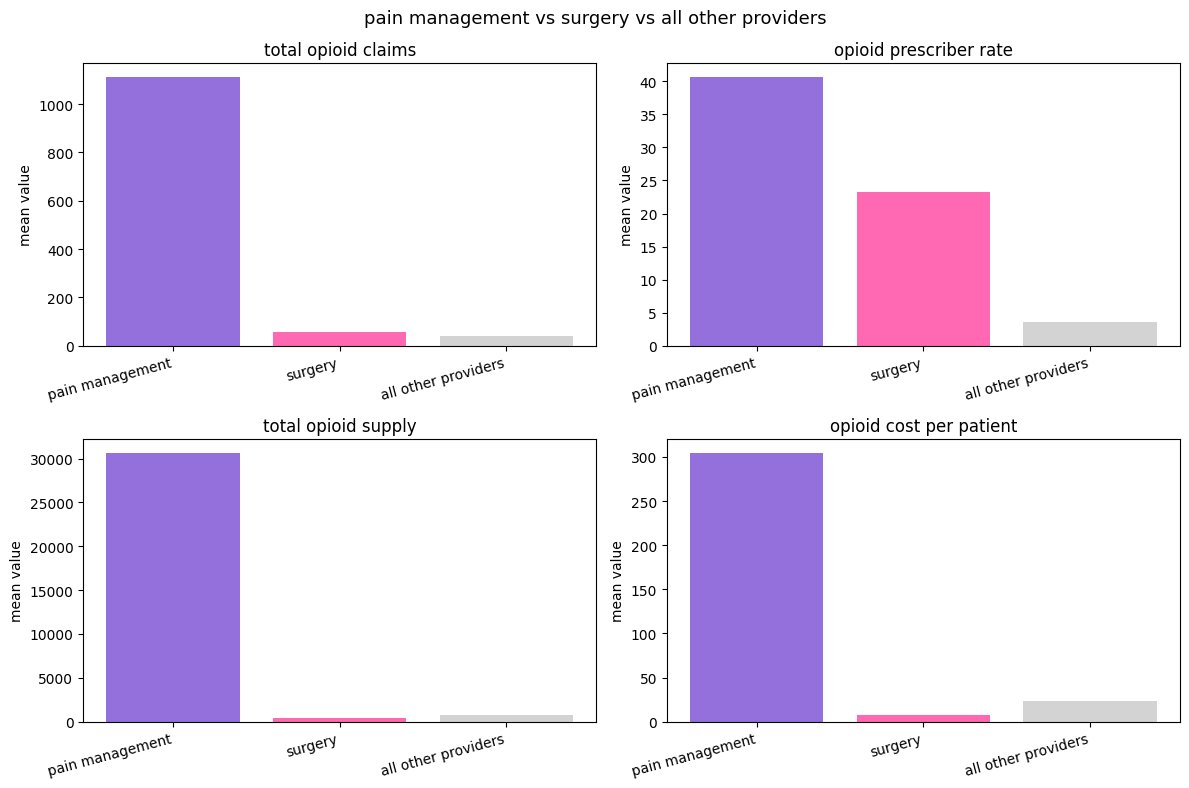

In [205]:
# Surgery vs Pain Management opioid comparison
surgery = df_op[df_op['Prscrbr_Type'].str.contains('Surgery|Surgical', case=False, na=False)]
pain = df_op[df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)]

groups = {
    'pain management': pain,
    'surgery': surgery,
    'all other providers': df_op[~df_op['Prscrbr_Type'].str.contains('Pain|Surgery|Surgical', case=False, na=False)]
}

metrics = ['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']
labels = ['total opioid claims', 'opioid prescriber rate', 'total opioid supply', 'opioid cost per patient']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(metrics, labels)):
    vals = [groups[g][metric].mean() for g in groups]
    axes[i].bar(groups.keys(), vals, color=['mediumpurple', 'hotpink', 'lightgray'])
    axes[i].set_title(label)
    axes[i].set_ylabel('mean value')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('pain management vs surgery vs all other providers', fontsize=13)
plt.tight_layout()
plt.show()

## Prescription Volume Distribution
### Small vs Large Prescribers

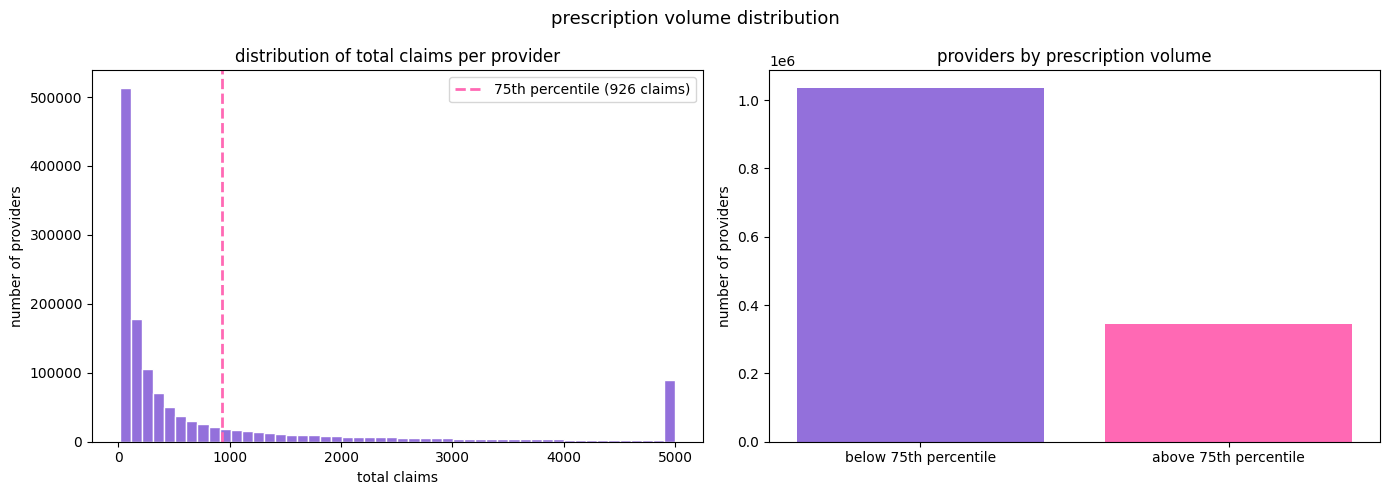

In [212]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

threshold = df_op['Tot_Clms'].quantile(0.75)

# histogram
axes[0].hist(df_op['Tot_Clms'].dropna().clip(upper=5000), bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('distribution of total claims per provider')
axes[0].set_xlabel('total claims')
axes[0].set_ylabel('number of providers')
axes[0].axvline(threshold, color='hotpink', linestyle='--', linewidth=2, label=f'75th percentile ({int(threshold)} claims)')
axes[0].legend()

# bar chart
axes[1].bar(['below 75th percentile', 'above 75th percentile'], 
            [1035539, 345126],
            color=['mediumpurple', 'hotpink'])
axes[1].set_title('providers by prescription volume')
axes[1].set_ylabel('number of providers')

plt.suptitle('prescription volume distribution', fontsize=13)
plt.tight_layout()
plt.show()